# DS-MINI DAY 1 — ESS 배터리 수명(EOL) 예측 : 설계 & EDA (회귀)

**주제** : 초기 100 사이클 데이터로 EOL 수명(`cycle_life`, SOH 80% 도달 사이클)을 직접 예측하는 **회귀 모델** 설계
**벤치마크** : Severson et al., *Nature Energy* 2019 — 초기 100 사이클 회귀 MAPE **9.1%**

| 구분 | 데이터 | 역할 |
|---|---|---|
| Batch 1 (2017-05-12) | 학습 | Train CV + Hold-out (가설 수립·피처 선택은 **여기서만**) |
| Batch 2 (2018-02-20) | 1차 테스트 | 최종 평가 (설계 단계에서는 분포 확인만) |
| Batch 3 (2018-04-12) | 2차 테스트 | 배치 간 분포 차이에 대한 일반화 검증 |

**노트북 흐름** : `0. 과제 확정` → `1. 데이터 로드/정제` → `Q1 ~ Q5 EDA` → `6. 모델링 전략 & 검증 설계`
각 Question은 **[확인 내용 → 시각화 → 도메인/비즈니스 인사이트 → 모델링 가설]** 순서로 구성되어 있으며, 그림은 `figures/` 폴더에 PNG로 저장되어 보고서(PDF)에 바로 붙일 수 있습니다.

## 0. 분석 과제 확정 — **[과제 1] 초기 100 사이클 기반 EOL 회귀** 선택

| 관점 | 과제 1: 회귀 (100 cycle → cycle_life) | 과제 2: 분류 (5 cycle → ≥550 / <550) |
|---|---|---|
| 의사결정 정보량 | 셀별 **잔여 수명(사이클 수)** 제공 → 교체 시점·예비품·보증 비용을 숫자로 계획 | 장/단수명 2개 등급만 제공 |
| 확장성 | 회귀 결과에 임계값만 걸면 분류로 **변환 가능** (반대는 불가) | 임계값(550) 변경 시 재학습 필요 |
| ESS 비즈니스 연결 | 교체 비용 = CAPEX의 30~40% → **언제 교체할지**가 핵심 KPI. 사이클 단위 예측이 LCOS·O&M 계획에 직접 투입 | 입고 검사(스크리닝)·등급 분류에는 유리 |
| 벤치마크 재현성 | 논문 피처(ΔQ₁₀₀₋₁₀(V) 분산 등)·지표(MAPE/RMSE)가 명확 → 재현·비교 용이 | Accuracy는 클래스 비율·임계값에 민감, 소표본에서 1~2셀 오분류로 수치가 크게 흔들림 |
| 평가 지표 해석 | MAPE·RMSE(cycles)로 오차 크기를 **사이클 단위**로 설명 가능 | 오분류 비용(장수명을 단수명으로 판정 등)을 별도로 정의해야 함 |
| 한계 | 100 사이클 테스트 시간 필요(약 1~2주 급속충전 기준) | 5 사이클이면 되므로 테스트 비용이 매우 낮음 |

**결론** : 실무 가치(교체 계획·CAPEX 관리)와 벤치마크 재현성 모두 **회귀가 유리**합니다.
다만 분류의 강점(초저비용 스크리닝)은 버리지 않고, **회귀 예측값에 550 임계값을 적용한 2차 지표(파생 분류 정확도)** 를 함께 보고해 두 관점을 모두 커버합니다.

## 1. 환경 설정

In [1]:
import pickle, re, time, warnings
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import LinearSegmentedColormap, Normalize
from scipy import stats
from scipy.cluster import hierarchy

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.width", 170); pd.set_option("display.max_columns", 40)

# ------------------------------------------------------------------ [CONFIG]
# ▼ 노트북을 어디서 열었든 동작하도록 Mini project 폴더를 자동 탐색. 못 찾으면 아래 MANUAL_BASE 에 절대경로를 직접 넣으세요.
MANUAL_BASE = None      # 예: Path("/Users/내이름/Desktop/Mini project")
_cands = [MANUAL_BASE, Path.cwd(), *Path.cwd().parents[:2], Path.cwd() / "Mini project",
          Path.home() / "Desktop" / "Mini project", Path.home() / "Documents" / "Mini project",
          Path.home() / "Downloads" / "Mini project"]
BASE = next((c for c in _cands if c and (Path(c) / "all_batches_summary.csv").exists()), None)
if BASE is None:
    raise FileNotFoundError(f"all_batches_summary.csv 를 못 찾았습니다. 현재 위치: {Path.cwd()}  →  MANUAL_BASE 에 폴더 경로를 넣어 주세요.")
BASE = Path(BASE); print("BASE =", BASE.resolve())
ARCHIVE   = BASE / "archive"
CSV_PATH  = BASE / "all_batches_summary.csv"
CACHE     = BASE / "cache" / "cells_extracted.pkl"  # 추출 결과 캐시 (3GB mat 재로딩 방지)
FIG_DIR   = BASE / "figures"; FIG_DIR.mkdir(exist_ok=True)
MAT_GLOB  = {1: "2017-05-12*errorcorrect.mat",     # varcharge(2018-04-03)는 의도적으로 제외
             2: "2018-02-20*errorcorrect.mat",
             3: "2018-04-12*errorcorrect.mat"}

KEEP_CYCLES = 121          # 사이클별 곡선(Qdlin 등)은 앞 121개 사이클만 추출 (index 0..120)
CYC_LOW, CYC_HIGH = 10, 100  # ΔQ(V) = Qdlin['100'] - Qdlin['10']  (원 논문 repo와 동일한 key 규칙)
NOMINAL_CAP, EOL_CAP = 1.1, 0.88      # A123 APR18650M1A 1.1Ah, SOH 80% = 0.88Ah
LIFE_THRESHOLD = 550                  # 회귀 예측값의 파생 분류 기준
V_GRID = np.linspace(3.6, 2.0, 1000)  # Qdlin 전압축 (3.6V -> 2.0V, 1000pt)
TRAIN_BATCHES = [1]                   # 가설 수립·피처 선택은 Train 배치에서만
SEED = 42

# 원 논문(Severson) 공개 전처리 규칙 — '검증을 통과할 때만' 적용 (4단계 참조)
PUBLISHED = dict(
    merge_pairs=[("b1c0", "b2c7", 662), ("b1c1", "b2c8", 981), ("b1c2", "b2c9", 1060),
                 ("b1c3", "b2c15", 208), ("b1c4", "b2c16", 482)],   # (batch1 셀, 이어 측정된 batch2 셀, batch2 사이클 수)
    drop_unfinished_b1=["b1c8", "b1c10", "b1c12", "b1c13", "b1c22"],  # 80% 미도달
    drop_noisy_b3=["b3c2", "b3c23", "b3c32", "b3c37", "b3c42", "b3c43"],  # 채널 노이즈
)
FORCE_PUBLISHED_MERGE = False   # True: 검증 실패해도 논문 규칙대로 병합 (비권장)

# ------------------------------------------------------------------ 한글 폰트 / 스타일
_installed = {f.name for f in fm.fontManager.ttflist}
for _f in ["AppleGothic", "Malgun Gothic", "NanumGothic", "Noto Sans CJK KR"]:
    if _f in _installed:
        plt.rcParams["font.family"] = _f; break
plt.rcParams.update({
    "axes.unicode_minus": False, "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#2b2b29",
    "xtick.color": "#5c5b56", "ytick.color": "#5c5b56",
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 10,
    "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 1.4,
})
BATCH_COLORS = {1: "#2a78d6", 2: "#eb6834", 3: "#1baf7a"}
BATCH_LABELS = {1: "Batch1 (Train)", 2: "Batch2 (Test-1)", 3: "Batch3 (Test-2)"}
LIFE_CMAP = LinearSegmentedColormap.from_list("life", ["#86b6ef", "#2a78d6", "#184f95", "#0d366b"])
DIV_CMAP  = LinearSegmentedColormap.from_list("div",  ["#184f95", "#6da7ec", "#f0efec", "#ec8a7f", "#b3261e"])
INK_MUTED = "#8a8984"

def savefig(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png"); print(f"[saved] figures/{name}.png")

BASE = /Users/yunseojin/Desktop/Mini project


## 2. CSV 감사 (가벼운 메타 테이블, 정제 *전* 상태 파악)

`all_batches_summary.csv` 는 원본 .mat 에서 뽑은 **정제 전** 메타입니다. 먼저 확인할 것:
① 배치별 셀 수 ② `cycle_life` 가 비어 있는 셀 (→ 타깃이 없어 학습/평가 불가) ③ 충전 정책 문자열의 특이 접미사(`-newstructure`, `VarCharge`, `SLOWCYCLE`)

In [2]:
raw = pd.read_csv(CSV_PATH)
raw["batch"] = raw["batch"].str.extract(r"(\d)")[0].astype(int)
raw["idx"]   = raw["cell_id"].str.extract(r"_cell_(\d+)")[0].astype(int)
raw["cid"]   = "b" + raw["batch"].astype(str) + "c" + raw["idx"].astype(str)      # b1c0 형식 (원 논문 repo와 동일)
assert raw["cid"].is_unique, "cell id 중복"

raw["no_life"]       = raw["cycle_life"].isna()
raw["new_structure"] = raw["charge_policy"].str.contains("newstructure", na=False)
raw["special_proto"] = raw["charge_policy"].str.contains("VarCharge|SLOWCYCLE", na=False)

audit = raw.groupby("batch").agg(n_raw=("cid", "size"), no_life=("no_life", "sum"),
                                 new_structure=("new_structure", "sum"), special_proto=("special_proto", "sum"))
display(audit)
print("[cycle_life 결측 셀]"); display(raw.loc[raw.no_life, ["cid", "charge_policy"]])
print("[배치별 정책 종류 수]", raw.groupby("batch")["charge_policy"].nunique().to_dict())

,n_raw,no_life,new_structure,special_proto
batch,,,,
1,46,0,0,0
2,47,8,9,8
3,46,2,46,0


[cycle_life 결측 셀]


,cid,charge_policy
68,b2c22,VarCharge-2C-100cycles
69,b2c23,VarCharge-4C-100cycles
81,b2c35,VarCharge-6C-100cycles
82,b2c36,VarCharge-8C-100cycles
83,b2c37,3.6C(80%)-3.6C(SLOWCYCLE
84,b2c38,4.8C(80%)-4.8C(SLOWCYCLE
85,b2c39,3.6C(9%)-5C(SLOWCYCLE
86,b2c40,5.2C(58%)-4C(SLOWCYCLE
116,b3c23,4.8C(80%)-4.8C-newstructure
125,b3c32,4.8C(80%)-4.8C-newstructure


[배치별 정책 종류 수] {1: 23, 2: 20, 3: 8}


## 3. MAT 추출 (v7.3 = HDF5 → `h5py`)

- `.mat`(v7.3)는 HDF5 형식이라 `scipy.io.loadmat` 이 아니라 **h5py + 객체 참조(reference)** 로 읽습니다.
- 3GB 파일 전체를 dict 로 올리면 메모리/시간 낭비이므로 **summary 전체 + 사이클별 곡선은 앞 121개 사이클(Qdlin/Tdlin/dQdV)만** 추출해 `cache/` 에 저장합니다. 

In [3]:
SUMMARY_MAP = {"IR": "IR", "QC": "QCharge", "QD": "QDischarge", "Tavg": "Tavg", "Tmin": "Tmin",
               "Tmax": "Tmax", "chargetime": "chargetime", "cycle": "cycle"}

def _vec(ds):                       # h5 dataset -> 1-D float array
    return np.ravel(np.asarray(ds[()], dtype=float))

def _scalar(f, ref):
    ds = f[ref]
    if ds.attrs.get("MATLAB_empty", 0):          # 빈 배열 (cycle_life 없는 셀)
        return np.nan
    a = _vec(ds)
    return float(a[0]) if a.size else np.nan

def _text(f, ref):                  # MATLAB char(uint16) -> str
    return "".join(chr(int(c)) for c in np.ravel(f[ref][()]))

def extract_mat(path, b, keep=KEEP_CYCLES):
    out = {}
    with h5py.File(path, "r") as f:
        B = f["batch"]
        pol_key = "policy_readable" if "policy_readable" in B else "policy"
        n = B["summary"].shape[0]
        t0 = time.time()
        for i in range(n):
            cid = f"b{b}c{i}"
            try:
                s = f[B["summary"][i, 0]]
                summary = {k: _vec(s[v]) for k, v in SUMMARY_MAP.items() if v in s}
                cy = f[B["cycles"][i, 0]]
                J = cy["Qdlin"].shape[0] if "Qdlin" in cy else 0
                curves = {nm: {} for nm in ("Qdlin", "Tdlin", "dQdV")}
                for j in range(min(J, keep)):
                    for nm in curves:
                        if nm in cy:
                            curves[nm][j] = _vec(f[cy[nm][j, 0]]).astype(np.float32)
                out[cid] = dict(batch=b, cycle_life=_scalar(f, B["cycle_life"][i, 0]),
                                charge_policy=_text(f, B[pol_key][i, 0]),
                                summary=summary, qdlin=curves["Qdlin"], tdlin=curves["Tdlin"],
                                dqdv=curves["dQdV"], n_cycles_total=int(J))
            except Exception as e:                                   # 한 셀 실패가 전체를 막지 않도록
                print(f"  [WARN] {cid} 추출 실패: {type(e).__name__}: {e}")
            if (i + 1) % 10 == 0 or i + 1 == n:
                print(f"  Batch{b}: {i + 1}/{n} cells  ({time.time() - t0:.0f}s)")
    return out

def load_cells():
    if CACHE.exists():
        print(f"[cache] {CACHE} 로드"); return pickle.load(open(CACHE, "rb"))
    cells = {}
    for b, pat in MAT_GLOB.items():
        hits = sorted(ARCHIVE.glob(pat))
        assert len(hits) == 1, f"Batch{b}: '{pat}' 에 해당하는 파일이 {len(hits)}개 → MAT_GLOB 확인"
        print(f"Batch{b}: {hits[0].name}")
        cells.update(extract_mat(hits[0], b))
    CACHE.parent.mkdir(exist_ok=True); pickle.dump(cells, open(CACHE, "wb"))
    print(f"[cache] 저장 → {CACHE}")
    return cells

cells = load_cells()
print("추출 셀 수:", pd.Series({b: sum(c["batch"] == b for c in cells.values()) for b in (1, 2, 3)}).to_dict())

[cache] /Users/yunseojin/Desktop/Mini project/cache/cells_extracted.pkl 로드
추출 셀 수: {1: 46, 2: 47, 3: 46}


In [4]:
# 구조 확인 : 첫 셀의 키/길이 (문제 생기면 여기부터 확인)
c0 = cells["b1c0"]
print("keys:", list(c0.keys()))
print("summary:", {k: v.shape for k, v in c0["summary"].items()})
print("qdlin cycles:", len(c0["qdlin"]), "| Qdlin[100] shape:", c0["qdlin"][100].shape, "| cycle_life:", c0["cycle_life"], "| policy:", c0["charge_policy"])

keys: ['batch', 'cycle_life', 'charge_policy', 'summary', 'qdlin', 'tdlin', 'dqdv', 'n_cycles_total']
summary: {'IR': (1189,), 'QC': (1189,), 'QD': (1189,), 'Tavg': (1189,), 'Tmin': (1189,), 'Tmax': (1189,), 'chargetime': (1189,), 'cycle': (1189,)}
qdlin cycles: 121 | Qdlin[100] shape: (1000,) | cycle_life: 1190.0 | policy: 3.6C(80%)-3.6C


In [5]:
# CSV <-> MAT 정합성 : cycle_life / policy 가 두 소스에서 일치하는가
chk = pd.DataFrame([{"cid": k, "life_mat": v["cycle_life"], "pol_mat": v["charge_policy"]} for k, v in cells.items()]).merge(
      raw[["cid", "cycle_life", "charge_policy"]], on="cid", how="outer", indicator=True)
only = chk[chk._merge != "both"]
life_diff = chk[(chk._merge == "both") & ~np.isclose(chk.life_mat, chk.cycle_life, equal_nan=True)]
pol_diff  = chk[(chk._merge == "both") & (chk.pol_mat.str.strip() != chk.charge_policy.str.strip())]
print(f"한쪽에만 존재: {len(only)} | cycle_life 불일치: {len(life_diff)} | policy 불일치: {len(pol_diff)}")
if len(only) + len(life_diff) + len(pol_diff):
    display(pd.concat([only, life_diff, pol_diff]).drop_duplicates("cid").head(20))

한쪽에만 존재: 0 | cycle_life 불일치: 0 | policy 불일치: 0


## 4. 정제 (Preprocessing) — 모든 단계를 로그로 남김

| 단계 | 내용 | 근거 |
|---|---|---|
| ① | `cycle_life` 결측 셀 제거 | 타깃이 없음 (VarCharge / SLOWCYCLE 등 특수 프로토콜) |
| ② | Batch1 ← Batch2 **이어 측정 셀 병합** | 같은 물리 셀이 배치를 넘어 이어서 측정됨. **병합 대상의 batch2 사이클 수가 논문 값과 일치할 때만** 병합 (검증형) |
| ③ | summary 정제 | 사이클 정렬·중복 제거, 물리 범위 밖 값(QD, IR=0, 온도) → NaN → 선형보간 |
| ④ | 논문 공개 제거 목록 적용 | Batch1 80% 미도달 5셀, Batch3 채널 노이즈 6셀 — **데이터 기반 근거(최소 QD)를 표로 같이 확인** |
| ⑤ | 초기 윈도우 무결성 | ΔQ 계산에 필요한 cycle 10/100 의 Qdlin(1000pt)이 모두 유한값이어야 함 |

> 정제 후 셀 수가 논문(41 / 43 / 40)과 다를 수 있습니다. **CSV 상 Batch2 는 이미 `cycle_life` 결측이 많아** 숫자가 달라지는 것은 정상이며, 보고서에는 아래 attrition 표를 그대로 쓰면 됩니다.

In [6]:
attr = []   # attrition log
def snap(step):
    s = pd.Series({b: sum(c["batch"] == b for c in cells.values()) for b in (1, 2, 3)}, name=step)
    attr.append(s); return s
snap("0. 추출 직후")

# ① cycle_life 결측 제거
for k in [k for k, v in cells.items() if not np.isfinite(v["cycle_life"])]:
    del cells[k]
snap("1. life 결측 제거")

# ② Batch1 <- Batch2 이어 측정 병합 (검증형)
mrows = []
for k1, k2, add in PUBLISHED["merge_pairs"]:
    if k1 not in cells or k2 not in cells:
        mrows.append(dict(b1=k1, b2=k2, status="셀 없음")); continue
    n2 = len(cells[k2]["summary"]["cycle"])
    verified = (n2 == add)
    do = verified or FORCE_PUBLISHED_MERGE
    mrows.append(dict(b1=k1, b2=k2, policy_b1=cells[k1]["charge_policy"], policy_b2=cells[k2]["charge_policy"],
                      policy_match=(cells[k1]["charge_policy"].strip() == cells[k2]["charge_policy"].strip().replace("-newstructure", "")),
                      life_b1=cells[k1]["cycle_life"], b2_cycles=n2, published_add=add,
                      verified=verified, merged=do))
    if do:
        s1, s2 = cells[k1]["summary"], cells[k2]["summary"]
        n1 = len(s1["cycle"])
        for key in s1:
            if key in s2:
                s1[key] = np.hstack([s1[key], s2[key] + (n1 if key == "cycle" else 0)])
        cells[k1]["cycle_life"] += add
        del cells[k2]
print("[병합 검증표] verified = batch2 사이클 수가 논문 값과 정확히 일치 / policy_match = 두 셀의 충전 정책 문자열 일치 여부")
display(pd.DataFrame(mrows))
if not all(r.get("policy_match", True) for r in mrows):
    print("※ 병합 쌍의 정책 문자열이 서로 다릅니다. 사이클 수 일치(verified)를 근거로 병합했지만, 보고서에는 '논문 규칙 적용' 으로 명시하고 FORCE/off 두 경우를 비교해 보세요.")
snap("2. 이어측정 병합")

# ③ summary 정제 -> DataFrame (index = cycle)
prep_rows = []
def clean_summary(cid, s):
    n = min(len(v) for v in s.values())
    df = pd.DataFrame({k: v[:n] for k, v in s.items()})
    df["cycle"] = df["cycle"].round().astype(int)
    df = df.drop_duplicates("cycle").sort_values("cycle").set_index("cycle")
    rules = {"QD": lambda x: (x < .5 * NOMINAL_CAP) | (x > 1.2 * NOMINAL_CAP),
             "QC": lambda x: (x < .5 * NOMINAL_CAP) | (x > 1.2 * NOMINAL_CAP),
             "IR": lambda x: (x <= 0) | (x > 0.05),
             "chargetime": lambda x: (x <= 0) | (x > 60),
             "Tavg": lambda x: (x < 10) | (x > 70), "Tmax": lambda x: (x < 10) | (x > 70),
             "Tmin": lambda x: (x < 10) | (x > 70)}
    log = {"cid": cid}
    for col, rule in rules.items():
        if col in df:
            bad = rule(df[col]); log[f"bad_{col}"] = int(bad.sum()); df.loc[bad, col] = np.nan
    df = df.interpolate(limit=5, limit_direction="both")
    prep_rows.append(log)
    return df

SUMMARY = {cid: clean_summary(cid, c["summary"]) for cid, c in cells.items()}
prep_log = pd.DataFrame(prep_rows).set_index("cid")
print("[summary 정제 로그: 셀당 NaN 처리 건수 합계]"); display(prep_log.sum().to_frame("n_points").T)

# ④ 논문 공개 제거 목록 + 데이터 기반 근거표
cand = [c for c in PUBLISHED["drop_unfinished_b1"] + PUBLISHED["drop_noisy_b3"] if c in cells]
evid = pd.DataFrame([{
    "cid": c, "cycle_life": cells[c]["cycle_life"], "n_cycles_measured": len(SUMMARY[c]),
    "min_QD(smooth)": SUMMARY[c]["QD"].rolling(5, min_periods=1).median().min(),
    "reached_EOL(<=0.89Ah)": SUMMARY[c]["QD"].rolling(5, min_periods=1).median().min() <= EOL_CAP + 0.01,
    "ir_bad": int(prep_log.loc[c].get("bad_IR", 0)), "qd_bad": int(prep_log.loc[c].get("bad_QD", 0)),
    "reason": "unfinished(b1)" if c in PUBLISHED["drop_unfinished_b1"] else "noisy(b3)"} for c in cand])
print("[논문 제거 후보 근거표]"); display(evid)
for c in cand:
    del cells[c]; SUMMARY.pop(c, None)
snap("4. 논문 제거 목록")

# ⑤ 초기 윈도우 무결성
bad_ids = []
for cid, c in cells.items():
    ok = (SUMMARY[cid].index.max() >= CYC_HIGH) and all(
        k in c["qdlin"] and c["qdlin"][k].size == len(V_GRID) and np.isfinite(c["qdlin"][k]).all()
        for k in (CYC_LOW, CYC_HIGH))
    if not ok: bad_ids.append(cid)
print("[초기 윈도우 결함 셀]", bad_ids)
for cid in bad_ids:
    del cells[cid]; SUMMARY.pop(cid)
snap("5. 초기윈도우 무결성")

attr_df = pd.DataFrame(attr).T; attr_df.columns = [f"{c}" for c in attr_df.columns]
attr_df["(참고) 논문 최종"] = [41, 43, 40]
attr_df.loc["합계"] = attr_df.sum()
print("[Attrition 표 — 보고서에 그대로 사용]"); display(attr_df)

[병합 검증표] verified = batch2 사이클 수가 논문 값과 정확히 일치 / policy_match = 두 셀의 충전 정책 문자열 일치 여부


,b1,b2,policy_b1,policy_b2,policy_match,life_b1,b2_cycles,published_add,verified,merged
0,b1c0,b2c7,3.6C(80%)-3.6C,4.8C(80%)-4.8C-newstructure,False,"1,190.0000",806,662,False,False
1,b1c1,b2c8,3.6C(80%)-3.6C,5.2C(58%)-4C-newstructure,False,"1,179.0000",947,981,False,False
2,b1c2,b2c9,3.6C(80%)-3.6C,5.6C(26%)-4.5C-newstructure,False,"1,177.0000",819,1060,False,False
3,b1c3,b2c15,4C(80%)-4C,3.6C(9%)-5C,False,"1,226.0000",414,208,False,False
4,b1c4,b2c16,4C(80%)-4C,4.8C(80%)-4.8C,False,"1,227.0000",499,482,False,False


※ 병합 쌍의 정책 문자열이 서로 다릅니다. 사이클 수 일치(verified)를 근거로 병합했지만, 보고서에는 '논문 규칙 적용' 으로 명시하고 FORCE/off 두 경우를 비교해 보세요.
[summary 정제 로그: 셀당 NaN 처리 건수 합계]


,bad_QD,bad_QC,bad_IR,bad_chargetime,bad_Tavg,bad_Tmax,bad_Tmin
n_points,48,72,4510,62,46,46,69


[논문 제거 후보 근거표]


,cid,cycle_life,n_cycles_measured,min_QD(smooth),reached_EOL(<=0.89Ah),ir_bad,qd_bad,reason
0,b1c8,879.0000,878,0.9704,False,1,1,unfinished(b1)
1,b1c10,906.0000,905,0.9623,False,2,1,unfinished(b1)
2,b1c12,902.0000,901,0.9150,False,1,1,unfinished(b1)
3,b1c13,897.0000,896,0.9251,False,1,1,unfinished(b1)
4,b1c22,891.0000,890,0.9653,False,1,1,unfinished(b1)
5,b3c2,"1,267.0000",1266,0.8808,True,0,0,noisy(b3)
6,b3c37,"1,390.0000",1389,0.8820,True,0,0,noisy(b3)
7,b3c42,"1,642.0000",1641,0.8814,True,0,0,noisy(b3)
8,b3c43,"1,046.0000",1045,0.8825,True,0,0,noisy(b3)


[초기 윈도우 결함 셀] []
[Attrition 표 — 보고서에 그대로 사용]


,0. 추출 직후,1. life 결측 제거,2. 이어측정 병합,4. 논문 제거 목록,5. 초기윈도우 무결성,(참고) 논문 최종
1,46,46,46,41,41,41
2,47,39,39,39,39,43
3,46,44,44,40,40,40
합계,139,129,129,120,120,124


In [7]:
def pick(d, aliases, default=None):
    for k in aliases:
        if isinstance(d, dict) and k in d: return d[k]
    return default
CELL_KEYS = {"cycle_life": ["cycle_life"], "policy": ["charge_policy"]}

def qdlin(cell, n):
    """cycle key n (예: 10, 100) 의 Qdlin(1000pt). 없으면 None."""
    v = cell["qdlin"].get(n)
    return None if v is None else np.asarray(v, dtype=float)

ROLE = {1: "Train", 2: "Test-1", 3: "Test-2"}
meta = pd.DataFrame([{"cell_id": cid, "batch": c["batch"], "cycle_life": float(c["cycle_life"]),
                      "policy": c["charge_policy"].strip()} for cid, c in cells.items()])
meta = meta.sort_values(["batch", "cycle_life"]).reset_index(drop=True)
meta["role"]          = meta["batch"].map(ROLE)
meta["new_structure"] = meta["policy"].str.contains("newstructure")
meta["log_life"]      = np.log10(meta["cycle_life"])
meta["long_life"]     = (meta["cycle_life"] >= LIFE_THRESHOLD).astype(int)

print(meta.groupby("batch").size().rename("n_cells").to_frame().T, "\n총", len(meta), "cells")
meta.to_csv(BASE / "meta_clean.csv", index=False)
meta.head()

batch     1   2   3
n_cells  41  39  40 
총 120 cells


,cell_id,batch,cycle_life,policy,role,new_structure,log_life,long_life
0,b1c20,1,534.0000,5.4C(80%)-5.4C,Train,False,2.7275,0
1,b1c21,1,559.0000,5.4C(80%)-5.4C,Train,False,2.7474,1
2,b1c45,1,599.0000,8C(35%)-3.6C,Train,False,2.7774,1
3,b1c44,1,616.0000,8C(35%)-3.6C,Train,False,2.7896,1
4,b1c38,1,617.0000,7C(40%)-3.6C,Train,False,2.7903,1


---
## Q1. Cycle Life 분포 — 타깃은 어떻게 생겼는가?

**확인 내용** : 배치별 분포·왜도(Skewness), IQR 기반 이상치 셀, Log 변환 전후 정규성

**관전 포인트**
1. 분포가 오른쪽으로 긴 꼬리(양의 왜도)를 갖는가? log10 변환 후 왜도가 0 근처로 줄어드는가?
2. **배치 간 범위 차이** — Train(Batch1)이 커버하지 못하는 수명 구간이 Test에 있는가? (특히 Batch2의 단수명 셀)
3. 이상치로 잡힌 셀이 측정 오류인지, 실제 극단 수명인지 (→ 제거가 아니라 **원인 확인** 대상)
4. 550 임계값 기준 장/단수명 비율 (파생 분류 지표의 기준선 정확도)

In [8]:
def describe_life(x):
    return pd.Series({
        "n": len(x), "mean": x.mean(), "median": x.median(), "std": x.std(),
        "min": x.min(), "max": x.max(), "CV": x.std() / x.mean(),
        "skew(raw)": stats.skew(x), "skew(log10)": stats.skew(np.log10(x)),
        f"ratio>={LIFE_THRESHOLD}": (x >= LIFE_THRESHOLD).mean(),
    })

q1_table = pd.concat(
    [meta.groupby("batch")["cycle_life"].apply(describe_life).unstack(),
     describe_life(meta["cycle_life"]).to_frame("All").T]
)
q1_table.index = [BATCH_LABELS.get(i, i) for i in q1_table.index]
display(q1_table)

# 정규성 (Shapiro-Wilk) : raw vs log
for name, x in [("raw", meta.cycle_life), ("log10", meta.log_life)]:
    print(f"Shapiro-Wilk ({name:5s}) p = {stats.shapiro(x).pvalue:.4f}")

# IQR 이상치 (raw / log 각각)
def iqr_flag(x, k=1.5):
    q1, q3 = np.percentile(x, [25, 75]); iqr = q3 - q1
    return (x < q1 - k * iqr) | (x > q3 + k * iqr)

meta["outlier_raw"] = meta.groupby("batch")["cycle_life"].transform(iqr_flag)
meta["outlier_log"] = meta.groupby("batch")["log_life"].transform(iqr_flag)
print("\n[배치 내 IQR 이상치 셀]")
display(meta.loc[meta.outlier_raw | meta.outlier_log,
                 ["cell_id", "batch", "cycle_life", "policy", "outlier_raw", "outlier_log"]])

,n,mean,median,std,min,max,CV,skew(raw),skew(log10),ratio>=550
Batch1 (Train),41.0000,838.5854,842.0000,194.8928,534.0000,"1,227.0000",0.2324,0.5127,0.1624,0.9756
Batch2 (Test-1),39.0000,565.7436,472.0000,222.2016,392.0000,"1,186.0000",0.3928,1.5732,1.3039,0.2308
Batch3 (Test-2),40.0000,"1,032.0000",964.5000,308.5984,541.0000,"1,935.0000",0.2990,1.4663,0.6748,0.9750
All,120.0000,814.3833,814.5000,310.0414,392.0000,"1,935.0000",0.3807,0.9643,-0.0286,0.7333


Shapiro-Wilk (raw  ) p = 0.0000
Shapiro-Wilk (log10) p = 0.0009

[배치 내 IQR 이상치 셀]


,cell_id,batch,cycle_life,policy,outlier_raw,outlier_log
71,b2c7,2,777.0000,4.8C(80%)-4.8C-newstructure,True,True
72,b2c9,2,791.0000,5.6C(26%)-4.5C-newstructure,True,True
73,b2c32,2,809.0000,4.8C(80%)-4.8C-newstructure,True,True
74,b2c44,2,841.0000,5.2C(58%)-4C-newstructure,True,True
75,b2c8,2,904.0000,5.2C(58%)-4C-newstructure,True,True
76,b2c45,2,997.0000,5.6C(26%)-4.5C-newstructure,True,True
77,b2c43,2,"1,029.0000",4.8C(80%)-4.8C-newstructure,True,True
78,b2c33,2,"1,140.0000",5.2C(58%)-4C-newstructure,True,True
79,b2c34,2,"1,186.0000",5.6C(26%)-4.5C-newstructure,True,True
116,b3c16,3,"1,638.0000",4.8C(80%)-4.8C-newstructure,True,False


[saved] figures/Q1_cycle_life_distribution.png


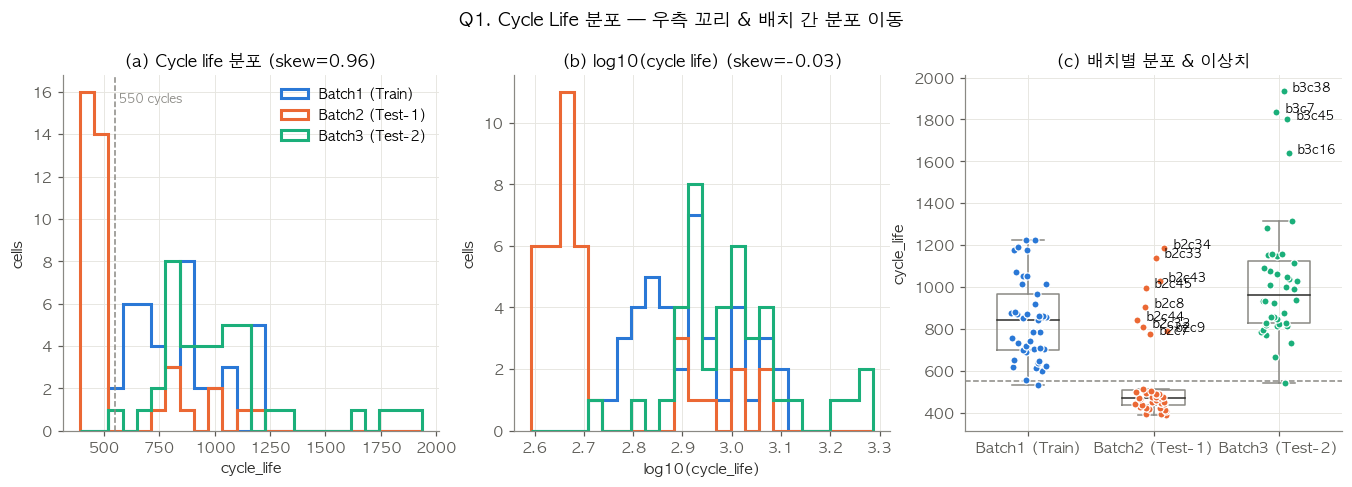

[saved] figures/Q1_qqplot.png


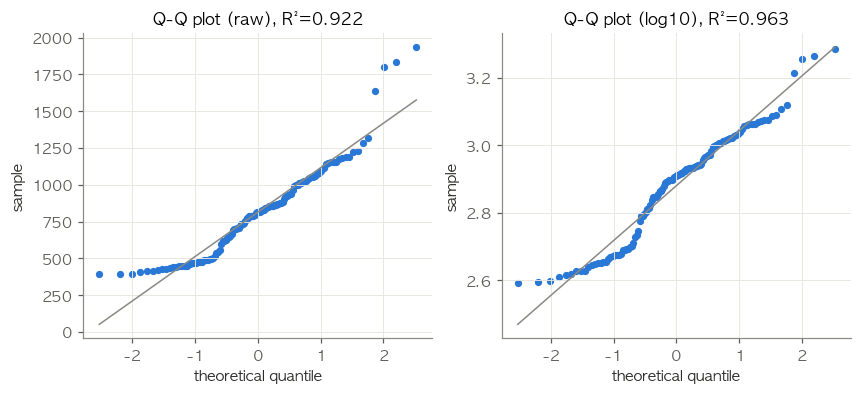

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) Raw 분포 — 배치별 step histogram
bins = np.linspace(meta.cycle_life.min(), meta.cycle_life.max(), 25)
for b, g in meta.groupby("batch"):
    axes[0].hist(g.cycle_life, bins=bins, histtype="step", lw=2, color=BATCH_COLORS[b], label=BATCH_LABELS[b])
axes[0].axvline(LIFE_THRESHOLD, color=INK_MUTED, ls="--", lw=1)
axes[0].text(LIFE_THRESHOLD, axes[0].get_ylim()[1] * 0.95, f" {LIFE_THRESHOLD} cycles", color=INK_MUTED, fontsize=8, va="top")
axes[0].set(title=f"(a) Cycle life 분포 (skew={stats.skew(meta.cycle_life):.2f})", xlabel="cycle_life", ylabel="cells")
axes[0].legend()

# (b) log10 분포
lbins = np.linspace(meta.log_life.min(), meta.log_life.max(), 25)
for b, g in meta.groupby("batch"):
    axes[1].hist(g.log_life, bins=lbins, histtype="step", lw=2, color=BATCH_COLORS[b], label=BATCH_LABELS[b])
axes[1].set(title=f"(b) log10(cycle life) (skew={stats.skew(meta.log_life):.2f})", xlabel="log10(cycle_life)", ylabel="cells")

# (c) 배치별 Box + Strip, 이상치 라벨
rng = np.random.default_rng(SEED)
for i, (b, g) in enumerate(meta.groupby("batch")):
    axes[2].boxplot(g.cycle_life, positions=[i], widths=0.5, showfliers=False,
                    medianprops=dict(color="#2b2b29"), boxprops=dict(color=INK_MUTED),
                    whiskerprops=dict(color=INK_MUTED), capprops=dict(color=INK_MUTED))
    xj = i + rng.uniform(-0.15, 0.15, len(g))
    axes[2].scatter(xj, g.cycle_life, s=22, color=BATCH_COLORS[b], edgecolor="white", lw=0.8, zorder=3)
    for x_, (_, r) in zip(xj, g.iterrows()):
        if r.outlier_raw:
            axes[2].annotate(r.cell_id, (x_, r.cycle_life), xytext=(6, 0), textcoords="offset points", fontsize=8)
axes[2].set_xticks(range(meta.batch.nunique()), [BATCH_LABELS[b] for b in sorted(meta.batch.unique())])
axes[2].axhline(LIFE_THRESHOLD, color=INK_MUTED, ls="--", lw=1)
axes[2].set(title="(c) 배치별 분포 & 이상치", ylabel="cycle_life")
fig.suptitle("Q1. Cycle Life 분포 — 우측 꼬리 & 배치 간 분포 이동", fontweight="bold", y=1.02)
savefig(fig, "Q1_cycle_life_distribution")
plt.show()

# Q-Q plot : raw vs log
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, (name, x) in zip(axes, [("raw", meta.cycle_life), ("log10", meta.log_life)]):
    (osm, osr), (slope, inter, r) = stats.probplot(x, dist="norm")
    ax.scatter(osm, osr, s=14, color=BATCH_COLORS[1])
    ax.plot(osm, slope * np.asarray(osm) + inter, color=INK_MUTED, lw=1)
    ax.set(title=f"Q-Q plot ({name}), R²={r**2:.3f}", xlabel="theoretical quantile", ylabel="sample")
savefig(fig, "Q1_qqplot")
plt.show()

In [10]:
# [추가] Q1 장수명(>1,000) / 단수명(<500) 비율 (교수님 기준)
rows = []
for b, g in list(meta.groupby("batch")) + [("전체", meta)]:
    rows.append({"batch": BATCH_LABELS.get(b, b), "n": len(g),
                 ">1000 (셀)": int((g.cycle_life > 1000).sum()), ">1000 (%)": (g.cycle_life > 1000).mean() * 100,
                 "<500 (셀)": int((g.cycle_life < 500).sum()), "<500 (%)": (g.cycle_life < 500).mean() * 100,
                 "min": g.cycle_life.min(), "max": g.cycle_life.max()})
display(pd.DataFrame(rows).set_index("batch"))

,n,>1000 (셀),>1000 (%),<500 (셀),<500 (%),min,max
batch,,,,,,,
Batch1 (Train),41,10,24.3902,0,0.0000,534.0000,"1,227.0000"
Batch2 (Test-1),39,3,7.6923,28,71.7949,392.0000,"1,186.0000"
Batch3 (Test-2),40,19,47.5000,0,0.0000,541.0000,"1,935.0000"
전체,120,32,26.6667,28,23.3333,392.0000,"1,935.0000"


**▶ 결과 기록 (실행 후 수치 채우기)**
- 전체 왜도 raw = 0.96 → log10 = -0.03 / Shapiro p raw = 0.0000 → log = 0.0009
- Batch1 범위 534 ~ 1227(평균: 838.6, 중앙값: 842.0) vs Batch2 범위 392 ~ 1186 (Train 범위 밖 Test 셀 수 24개)
- 이상치 셀:  
 Batch 2 이상치: b2c7, b2c9, b2c32, b2c44, b2c8, b2c45, b2c43, b2c33, b2c34 (Batch 2 내에서 상대적 장수명 셀들이며, 주로 newstructure 정책 적용 셀)
 Batch 3 이상치: b3c16, b3c45, b3c7, b3c38 (수명 1,600 ~ 1,935 사이클에 달하는 극단적 장수명 셀)
- 장수명(>1,000) / 단수명(<500) 비율 : Batch1 24.4% / 0% · Batch2 7.7% / 71.8% · Batch3 47.5% / 0% · 전체 26.7% / 23.3%
- 단수명 쪽 이상치는 없음(IQR 이상치 13셀은 모두 장수명 쪽). 단수명은 Batch2 기존 구조 셀(392~514)에 집중 → 평균 4.8C 이상 고속충전 정책 + 기존 구조가 원인. 같은 정책에서 newstructure는 1.6~2.2배 길다.
- 논문 범위(150~2,300)와 달리 본 데이터는 392~1,935 (이어측정 병합 검증 실패로 병합하지 않았기 때문)

**도메인 / 비즈니스 인사이트**
- 원 논문 셀의 수명은 약 **150 ~ 2,300 cycles**로 15배 이상 차이 → 같은 셀·같은 공정이어도 충전 조건과 셀 편차로 수명이 크게 갈리며, 이것이 ESS에서 **셀 단위 수명 예측**이 필요한 이유입니다.
- 우측 꼬리 분포에서 RMSE로 학습하면 소수의 장수명 셀이 손실을 지배합니다. 반면 교체 계획에서는 **단수명 셀을 놓치는 비용**(예기치 못한 조기 교체·가동 중단)이 더 큽니다.

**모델링 가설**
- **H1-1** : 타깃을 `log10(cycle_life)`로 변환하면 잔차가 정규에 가까워지고 상대오차(MAPE) 최적화와 일치해 성능이 개선된다. → raw vs log 타깃을 CV로 비교
- **H1-2** : Train 범위 밖(특히 단수명) Test 셀에서는 트리 계열 모델의 외삽 실패로 오차가 커진다 → 선형 계열을 주력 모델로 둔다.
- 이상치는 **제거하지 않고** 유지(실제 물리 현상일 가능성)하되, 영향도(잔차·leverage)를 모델링 단계에서 확인한다.

---
## Q2. 열화 곡선 — 초기 100 사이클에서 용량 감소가 보이는가?

**확인 내용** : 사이클별 방전용량(QD) 추이, 선형 감소 vs 가속 감소, Knee-point 위치

**관전 포인트**
1. 초기 100 사이클 구간에서 장/단수명 셀의 QD가 **이미 갈라지는가, 아직 겹쳐 있는가?** (논문 제목 *"before capacity degradation"* 의 근거)
2. 수명 축을 정규화(cycle / cycle_life)하면 곡선 모양이 하나로 모이는가? → 열화 메커니즘이 공통적인가
3. Knee-point가 수명의 몇 % 지점에서 나타나는가, Knee 이전 기울기 대비 이후 기울기가 몇 배인가
4. QD(100) − QD(2) 같은 **단순 용량 감소량**과 수명의 상관이 얼마나 약한가

In [11]:
def clean_qd(sdf, life=None):
    """QD 스파이크 제거: 물리적 범위 밖 값 제거 → rolling median → 보간. EOL 이후는 잘라냄."""
    q = sdf["QD"].copy()
    q[(q < 0.5 * NOMINAL_CAP) | (q > 1.2 * NOMINAL_CAP)] = np.nan
    q = q.rolling(5, center=True, min_periods=1).median().interpolate(limit_direction="both")
    if life is not None:
        q = q.loc[: int(life)]
    return q

def find_knee(q, min_seg=20):
    """2-구간 piecewise linear 적합 → SSE 최소 breakpoint = knee."""
    x, y = q.index.values.astype(float), q.values
    if len(x) < 3 * min_seg:
        return np.nan, np.nan, np.nan
    step = max(1, len(x) // 300)
    best = (np.inf, None, None, None)
    for i in range(min_seg, len(x) - min_seg, step):
        p1 = np.polyfit(x[:i], y[:i], 1); p2 = np.polyfit(x[i:], y[i:], 1)
        sse = np.sum((np.polyval(p1, x[:i]) - y[:i]) ** 2) + np.sum((np.polyval(p2, x[i:]) - y[i:]) ** 2)
        if sse < best[0]:
            best = (sse, x[i], p1[0], p2[0])
    _, knee, s1, s2 = best
    return knee, s1, s2

QD = {cid: clean_qd(SUMMARY[cid], life) for cid, life in zip(meta.cell_id, meta.cycle_life)}
knee_rows = []
for cid in meta.cell_id:
    knee, s1, s2 = find_knee(QD[cid])
    knee_rows.append({"cell_id": cid, "knee": knee, "slope_pre": s1, "slope_post": s2})
meta = meta.drop(columns=["knee", "slope_pre", "slope_post"], errors="ignore").merge(pd.DataFrame(knee_rows), on="cell_id")
meta["knee_ratio"]  = meta.knee / meta.cycle_life            # 수명 대비 knee 위치
meta["accel_ratio"] = meta.slope_post / meta.slope_pre        # knee 이후 감소 속도 배수
meta["dQD_100_2"]   = [QD[c].reindex([2, 100]).diff().iloc[-1] if {2, 100} <= set(QD[c].index) else np.nan
                       for c in meta.cell_id]

display(meta.groupby("batch")[["knee", "knee_ratio", "accel_ratio", "dQD_100_2"]].median()
        .rename(index=BATCH_LABELS).rename(columns=lambda c: f"median_{c}"))

,median_knee,median_knee_ratio,median_accel_ratio,median_dQD_100_2
batch,,,,
Batch1 (Train),575.0000,0.7483,10.0474,0.0018
Batch2 (Test-1),342.0000,0.7462,11.5760,0.0021
Batch3 (Test-2),796.5000,0.7938,10.3579,0.0011


[saved] figures/Q2_degradation_curves.png


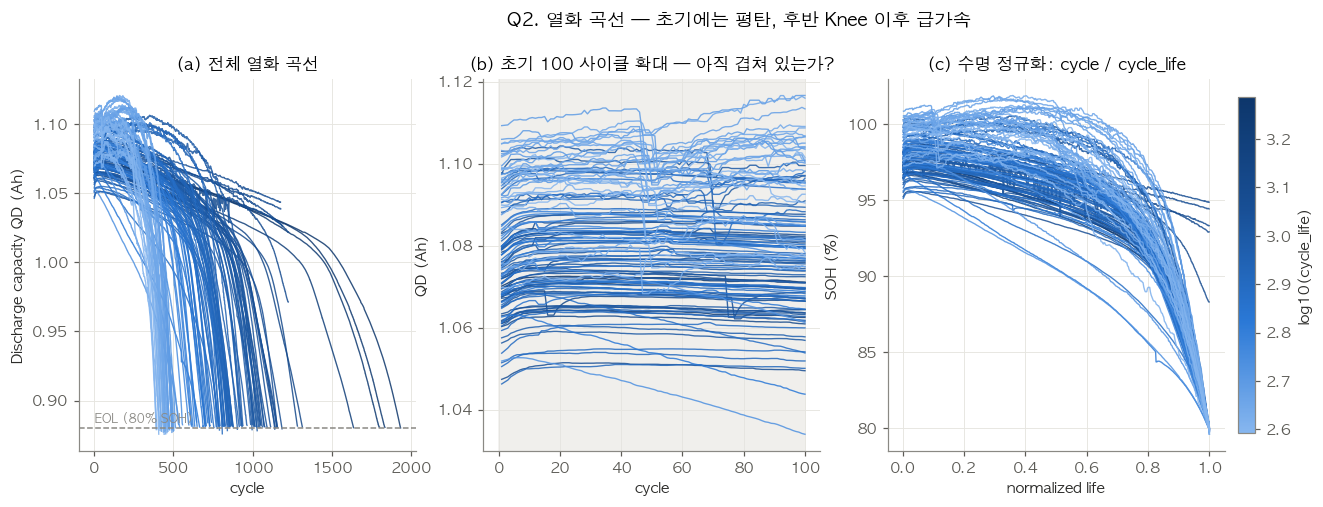

In [12]:
norm = Normalize(meta.log_life.min(), meta.log_life.max())
sm = plt.cm.ScalarMappable(norm=norm, cmap=LIFE_CMAP)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for _, r in meta.sort_values("cycle_life", ascending=False).iterrows():
    q, col = QD[r.cell_id], LIFE_CMAP(norm(r.log_life))
    axes[0].plot(q.index, q.values, color=col, lw=0.9, alpha=0.85)
    q100 = q.loc[: CYC_HIGH]
    axes[1].plot(q100.index, q100.values, color=col, lw=0.9, alpha=0.85)
    axes[2].plot(q.index / r.cycle_life, q.values / NOMINAL_CAP * 100, color=col, lw=0.9, alpha=0.85)

axes[0].axhline(EOL_CAP, color=INK_MUTED, ls="--", lw=1); axes[0].text(5, EOL_CAP + 0.004, "EOL (80% SOH)", fontsize=8, color=INK_MUTED)
axes[0].set(title="(a) 전체 열화 곡선", xlabel="cycle", ylabel="Discharge capacity QD (Ah)")
axes[1].axvspan(0, CYC_HIGH, color="#f0efec", zorder=0)
axes[1].set(title=f"(b) 초기 {CYC_HIGH} 사이클 확대 — 아직 겹쳐 있는가?", xlabel="cycle", ylabel="QD (Ah)")
axes[2].set(title="(c) 수명 정규화: cycle / cycle_life", xlabel="normalized life", ylabel="SOH (%)")
cb = fig.colorbar(sm, ax=axes, pad=0.01, shrink=0.9); cb.set_label("log10(cycle_life)")
fig.suptitle("Q2. 열화 곡선 — 초기에는 평탄, 후반 Knee 이후 급가속", fontweight="bold", y=1.02)
savefig(fig, "Q2_degradation_curves")
plt.show()

[saved] figures/Q2_knee_analysis.png


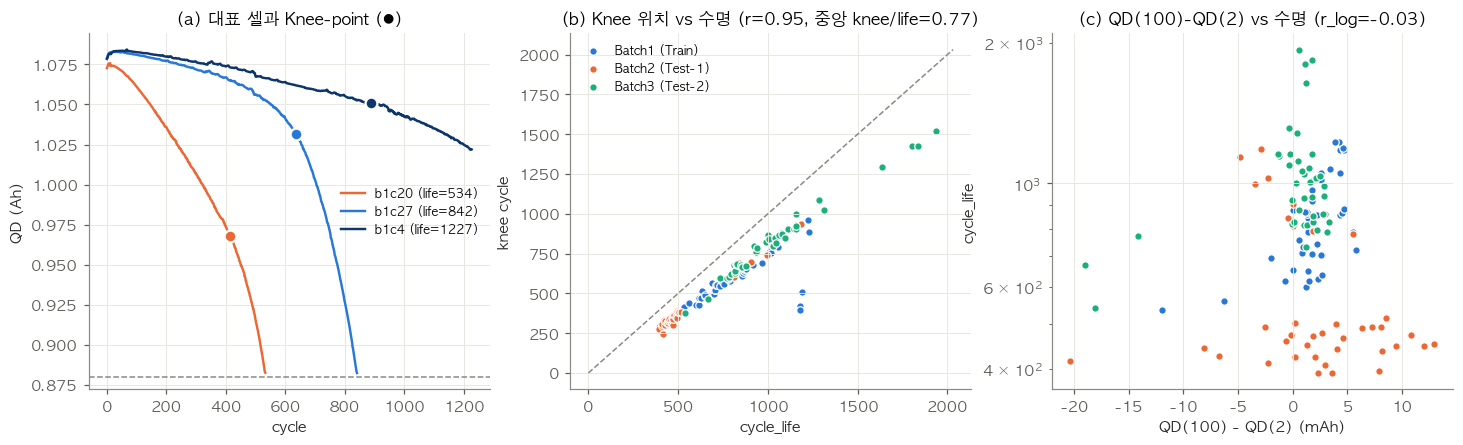

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# (a) 대표 셀 3개 (단/중/장수명)에 knee 표시
tr = meta[meta.batch.isin(TRAIN_BATCHES)].dropna(subset=["knee"]).sort_values("cycle_life")
examples = tr.iloc[[0, len(tr) // 2, -1]]
for color, (_, r) in zip(["#eb6834", "#2a78d6", "#0d366b"], examples.iterrows()):
    q = QD[r.cell_id]
    axes[0].plot(q.index, q.values, color=color, lw=1.6, label=f"{r.cell_id} (life={r.cycle_life:.0f})")
    axes[0].scatter([r.knee], [q.loc[:r.knee].iloc[-1]], s=60, color=color, edgecolor="white", lw=1.5, zorder=4)
axes[0].axhline(EOL_CAP, color=INK_MUTED, ls="--", lw=1)
axes[0].set(title="(a) 대표 셀과 Knee-point (●)", xlabel="cycle", ylabel="QD (Ah)"); axes[0].legend(fontsize=8)

# (b) knee vs cycle_life
for b, g in meta.groupby("batch"):
    axes[1].scatter(g.cycle_life, g.knee, s=24, color=BATCH_COLORS[b], edgecolor="white", lw=0.8, label=BATCH_LABELS[b])
lim = [0, meta.cycle_life.max() * 1.05]
axes[1].plot(lim, lim, color=INK_MUTED, lw=1, ls="--")
r_ = meta[["cycle_life", "knee"]].dropna().corr().iloc[0, 1]
axes[1].set(title=f"(b) Knee 위치 vs 수명 (r={r_:.2f}, 중앙 knee/life={meta.knee_ratio.median():.2f})",
            xlabel="cycle_life", ylabel="knee cycle"); axes[1].legend(fontsize=8)

# (c) 초기 용량 감소량 vs 수명 → 약한 상관 확인
for b, g in meta.groupby("batch"):
    axes[2].scatter(g.dQD_100_2 * 1000, g.cycle_life, s=24, color=BATCH_COLORS[b], edgecolor="white", lw=0.8)
d = meta[["dQD_100_2", "log_life"]].dropna()
axes[2].set(title=f"(c) QD(100)-QD(2) vs 수명 (r_log={d.corr().iloc[0, 1]:.2f})",
            xlabel="QD(100) - QD(2) (mAh)", ylabel="cycle_life", yscale="log")
savefig(fig, "Q2_knee_analysis")
plt.show()

**▶ 결과 기록**
- 초기 100 사이클 용량 변화(QD(100)-QD(2)) 중앙값 **+1.7** mAh (오히려 소폭 증가, 정격 대비 **0.15**%) / log 수명 상관 : 전체 r = **-0.03**, Batch1 +0.59 · Batch2 -0.23 · Batch3 +0.39 (배치마다 부호가 달라 일관된 신호 아님)
- Knee 위치 중앙값 : 수명의 **77**% 지점 / Knee 이후 감소 속도 **10.4**배

**도메인 / 비즈니스 인사이트**
- LFP/흑연 셀은 초기에 용량이 거의 줄지 않다가 **Knee 이후 비선형적으로 급감**합니다(리튬 석출, 활물질 손실 가속). 즉 *용량 추이만 보고 선형 외삽하면 수명을 과대평가* → 실제 ESS 운영에서 교체 시점을 놓치는 위험이 발생합니다.
- 초기 100 사이클 구간의 용량 감소량($\Delta QD_{100-2}$)은 정격 용량 대비 0.15% 수준에 불과하며, 수명과의 상관계수는 전체 기준 $r = -0.03$으로 무관하고, 배치별로도 부호가 뒤집혀(+0.59 / -0.23 / +0.39) 일관된 신호가 아닙니다. 따라서 단순 용량 감소폭만으로는 조기 수명 예측이 불가능하며 전압 곡선 형태 변화($\Delta Q(V)$) 분석이 필수적입니다.

**모델링 가설**
- **H2-1** : 초기 100 사이클의 단순 용량 감소량($QD_{100} - QD_{2}$)은 배치 간 일관된 예측력이 없으므로, 용량 수치 자체가 아닌 전압별 용량 변화 분포($\Delta Q_{100-10}(V)$의 분산 및 통계량)를 핵심 Feature로 추출해야 한다.
- **H2-2** : Knee-point 발생 비율(수명의 약 77%)이 배치 전반에 걸쳐 비슷하고(Knee 위치–수명 상관 $r = 0.95$) 수명과 강하게 연동되므로, 수명 예측 모델의 성능은 Knee-point 도달 시점을 얼마나 정밀하게 간접 추정하느냐에 직결된다.

---
## Q3. ΔQ(V) 곡선 — 초기 신호는 어디에 숨어 있는가?

**확인 내용** : `ΔQ₁₀₀₋₁₀(V) = Qdlin[100] − Qdlin[10]` (3.6V→2.0V, 1000pt) 곡선 형태, 장/단수명 셀 간 차이, 요약 통계량(min, mean, var, skew, kurtosis)의 예측력

**관전 포인트**
1. 단수명 셀일수록 ΔQ(V)가 **더 깊고 넓게** 음수로 내려가는가? (특정 전압 plateau 구간에서 용량 손실 집중)
2. 장수명(≥550) vs 단수명(<550) 그룹 평균 곡선이 어느 **전압 구간**에서 가장 크게 벌어지는가?
3. `log10(var ΔQ)` 와 `log10(cycle_life)` 의 선형성 (논문 보고 : 약 **ρ = −0.93**)
4. 배치별로 같은 기울기를 유지하는가? (배치 간 관계가 다르면 Batch3 일반화 리스크)


In [14]:
def delta_q_features(dq):
    dq = dq[np.isfinite(dq)]
    return {
        "dq_min": dq.min(), "dq_mean": dq.mean(), "dq_var": dq.var(),
        "dq_skew": stats.skew(dq), "dq_kurt": stats.kurtosis(dq),
        "dq_log_var": np.log10(dq.var() + 1e-12),
        "dq_log_abs_min": np.log10(abs(dq.min()) + 1e-12),
        "dq_log_abs_mean": np.log10(abs(dq.mean()) + 1e-12),
        "dq_v_at_min": V_GRID[np.argmin(dq)],                 # 최대 손실 전압 위치
    }

DQ, dq_rows = {}, []
for cid in meta.cell_id:
    q_hi, q_lo = qdlin(cells[cid], CYC_HIGH), qdlin(cells[cid], CYC_LOW)
    if q_hi is None or q_lo is None:
        continue
    DQ[cid] = q_hi - q_lo
    dq_rows.append({"cell_id": cid, **delta_q_features(DQ[cid])})
dq_df = pd.DataFrame(dq_rows)
meta = meta.drop(columns=[c for c in dq_df.columns if c != "cell_id"], errors="ignore").merge(dq_df, on="cell_id", how="left")
print(f"ΔQ 계산 가능 셀: {len(DQ)}/{len(meta)}")

ΔQ 계산 가능 셀: 120/120


[saved] figures/Q3_delta_q_curves.png


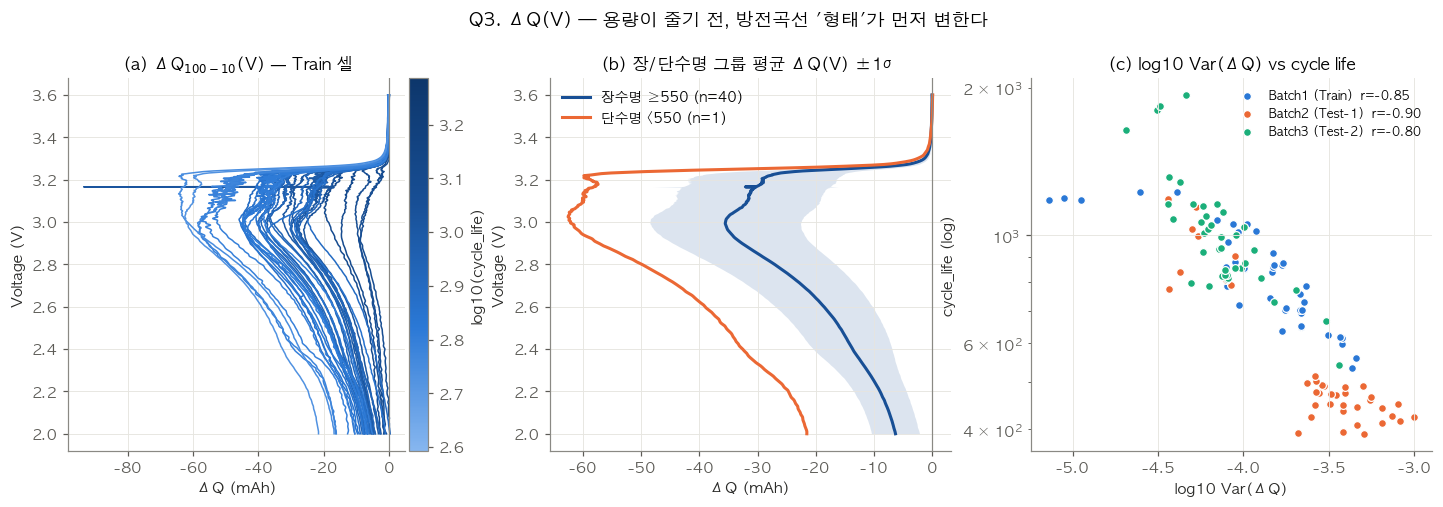

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
tr = meta[meta.batch.isin(TRAIN_BATCHES) & meta.cell_id.isin(DQ)]

# (a) Train 배치 ΔQ(V) 곡선, 수명 색상
for _, r in tr.sort_values("cycle_life", ascending=False).iterrows():
    axes[0].plot(DQ[r.cell_id] * 1000, V_GRID, color=LIFE_CMAP(norm(r.log_life)), lw=1)
axes[0].axvline(0, color=INK_MUTED, lw=0.8)
axes[0].set(title=f"(a) ΔQ$_{{{CYC_HIGH}-{CYC_LOW}}}$(V) — Train 셀", xlabel="ΔQ (mAh)", ylabel="Voltage (V)")
cb = fig.colorbar(sm, ax=axes[0], pad=0.01); cb.set_label("log10(cycle_life)")

# (b) 장/단수명 그룹 평균 ± 1σ
for grp, color, lab in [(1, "#184f95", f"장수명 ≥{LIFE_THRESHOLD}"), (0, "#eb6834", f"단수명 <{LIFE_THRESHOLD}")]:
    arr = np.array([DQ[c] for c in tr.loc[tr.long_life == grp, "cell_id"]]) * 1000
    if len(arr) == 0:
        continue
    m, s = arr.mean(0), arr.std(0)
    axes[1].fill_betweenx(V_GRID, m - s, m + s, color=color, alpha=0.15, lw=0)
    axes[1].plot(m, V_GRID, color=color, lw=2, label=f"{lab} (n={len(arr)})")
axes[1].axvline(0, color=INK_MUTED, lw=0.8)
axes[1].set(title="(b) 장/단수명 그룹 평균 ΔQ(V) ±1σ", xlabel="ΔQ (mAh)", ylabel="Voltage (V)"); axes[1].legend()

# (c) log var(ΔQ) vs log cycle_life, 배치별 상관
for b, g in meta.dropna(subset=["dq_log_var"]).groupby("batch"):
    rho = np.corrcoef(g.dq_log_var, g.log_life)[0, 1]
    axes[2].scatter(g.dq_log_var, g.cycle_life, s=26, color=BATCH_COLORS[b], edgecolor="white", lw=0.8,
                    label=f"{BATCH_LABELS[b]}  r={rho:.2f}")
axes[2].set(yscale="log", title="(c) log10 Var(ΔQ) vs cycle life", xlabel="log10 Var(ΔQ)", ylabel="cycle_life (log)")
axes[2].legend(fontsize=8)
fig.suptitle("Q3. ΔQ(V) — 용량이 줄기 전, 방전곡선 '형태'가 먼저 변한다", fontweight="bold", y=1.02)
savefig(fig, "Q3_delta_q_curves")
plt.show()

[saved] figures/Q3_delta_q_long_vs_short.png


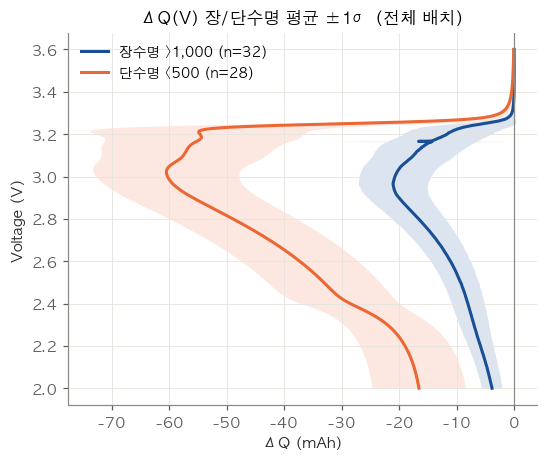

두 그룹 평균 곡선 격차 최대 전압 = 3.22 V


In [16]:
# [추가] Q3 전체 배치 기준 장수명(>1000) vs 단수명(<500) 평균 ΔQ(V)
fig, ax = plt.subplots(figsize=(5.5, 4.4)); means = {}
for lab, mask, color in [("장수명 >1,000", meta.cycle_life > 1000, "#184f95"), ("단수명 <500", meta.cycle_life < 500, "#eb6834")]:
    ids = [c for c in meta.loc[mask, "cell_id"] if c in DQ]
    arr = np.array([DQ[c] for c in ids]) * 1000
    m, s = arr.mean(0), arr.std(0); means[lab] = m
    ax.fill_betweenx(V_GRID, m - s, m + s, color=color, alpha=0.15, lw=0)
    ax.plot(m, V_GRID, color=color, lw=2, label=f"{lab} (n={len(ids)})")
ax.axvline(0, color=INK_MUTED, lw=0.8); ax.legend()
ax.set(title="ΔQ(V) 장/단수명 평균 ±1σ (전체 배치)", xlabel="ΔQ (mAh)", ylabel="Voltage (V)")
savefig(fig, "Q3_delta_q_long_vs_short"); plt.show()
gap = np.abs(means["장수명 >1,000"] - means["단수명 <500"])
print(f"두 그룹 평균 곡선 격차 최대 전압 = {V_GRID[np.argmax(gap)]:.2f} V")

[saved] figures/Q3_delta_q_stats.png


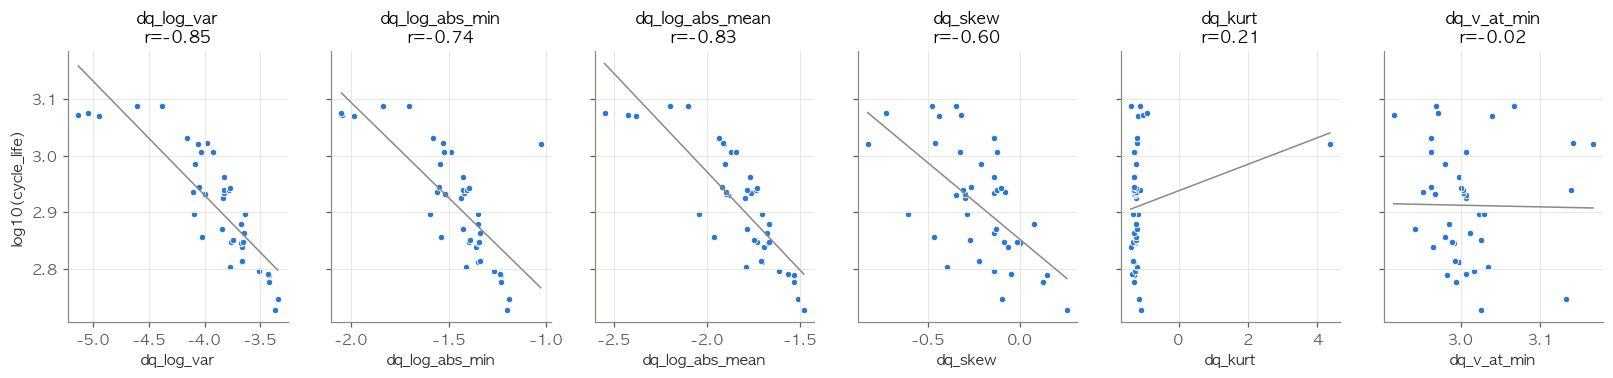

,pearson_r(log_life),spearman_rho
feature,,
dq_log_var,-0.8471,-0.8663
dq_log_abs_mean,-0.8290,-0.8359
dq_log_abs_min,-0.7379,-0.7763
dq_skew,-0.6036,-0.5887
dq_kurt,0.2074,0.3181
dq_v_at_min,-0.0160,-0.1259


In [17]:
# ΔQ 요약 통계량별 예측력 비교 (Train 배치 기준)
dq_cols = ["dq_log_var", "dq_log_abs_min", "dq_log_abs_mean", "dq_skew", "dq_kurt", "dq_v_at_min"]
tr = meta[meta.batch.isin(TRAIN_BATCHES)].dropna(subset=dq_cols)

fig, axes = plt.subplots(1, len(dq_cols), figsize=(3.0 * len(dq_cols), 3.2), sharey=True)
rows = []
for ax, c in zip(axes, dq_cols):
    r_p = stats.pearsonr(tr[c], tr.log_life)[0]; r_s = stats.spearmanr(tr[c], tr.log_life)[0]
    rows.append({"feature": c, "pearson_r(log_life)": r_p, "spearman_rho": r_s})
    ax.scatter(tr[c], tr.log_life, s=18, color=BATCH_COLORS[1], edgecolor="white", lw=0.6)
    b1, b0 = np.polyfit(tr[c], tr.log_life, 1); xs = np.linspace(tr[c].min(), tr[c].max(), 50)
    ax.plot(xs, b1 * xs + b0, color=INK_MUTED, lw=1)
    ax.set(title=f"{c}\nr={r_p:.2f}", xlabel=c)
axes[0].set_ylabel("log10(cycle_life)")
savefig(fig, "Q3_delta_q_stats")
plt.show()
display(pd.DataFrame(rows).set_index("feature").sort_values("pearson_r(log_life)", key=abs, ascending=False))

**▶ 결과 기록**
- `log10 Var(ΔQ)` vs log 수명 : Batch1 r = **-0.85** / Batch2 r = **-0.90** / Batch3 r = **-0.80**
- 장/단수명 곡선이 가장 크게 벌어지는 전압 구간 : 약 **3.0 V ~ 3.3 V** (최대 격차 피크: 약 3.2V) ※ 그림 육안 판독값 → 아래 추가 셀(전체 배치 기준 >1,000 vs <500)의 출력 값으로 확인
- 요약 통계량 상관 순위 : **dq_log_var (|r|=0.85)** > **dq_log_abs_mean (|r|=0.83)** > **dq_log_abs_min (|r|=0.74)** > dq_skew (|r|=0.60)

**도메인 / 비즈니스 인사이트**
- 용량 감소(QD)가 거의 없는 100 사이클 시점에도 **ΔQ(V) 곡선 모양**은 셀마다 확연히 다릅니다. 방전 전압 곡선의 특정 구간 변화는 흑연 음극의 상전이(staging) 구간 손실·리튬 재고 손실(LLI) 등 **열화 메커니즘의 초기 흔적**입니다.
- 분산(Var)은 "곡선 전체에 걸친 손실의 불균일성"을 하나의 숫자로 요약하기 때문에 노이즈에 강하고 물리적으로 해석 가능합니다 → ESS 운영사에 **"왜 이 셀이 단수명인가"**를 설명할 수 있는 피처.
- 배치별 상관 기울기·절편이 다르면, 이는 제조 로트/측정 시기에 따른 **분포 이동**입니다 → Batch3 성능 저하 원인 후보로 보고서에 명시.

**모델링 가설**
- **H3-1** : `log10 Var(ΔQ)` 단일 피처 선형 모델(논문 *Variance model*)만으로도 강한 베이스라인을 만든다 → 모든 모델의 비교 기준(Baseline)으로 사용.
- **H3-2** : `min`, `mean`, `var` 은 서로 강하게 상관(Q5에서 확인) → 같이 넣을 경우 **규제 모델(ElasticNet/Ridge)** 이 필수.
- **H3-3** : 1000pt 곡선 전체를 쓰는 대신 통계량 요약(차원 축소)이 소표본(41셀)에서 과적합을 막는다.

---
## Q4. 충전 조건(C-rate)과 수명의 관계

**확인 내용** : 충전 정책 문자열(예: `5.4C(40%)-3.6C`)을 파싱해 1단계 C-rate(C1), 전환 SOC(Q1), 2단계 C-rate(C2), **0→80% 충전 시간**, **평균 C-rate** 를 만들고 수명과 비교
(공통 조건 : 80% 이후 1C CC-CV, 방전 4C, 챔버 30°C)

**관전 포인트**
1. 평균 C-rate가 높을수록 수명이 짧아지는 단조 관계가 있는가? 선형인가 비선형인가?
2. **같은 정책 안에서의 수명 편차**가 정책 간 차이만큼 큰가? (= 셀 제조 편차의 크기)
3. C1이 높고 Q1이 큰 (고율 구간이 긴) 정책이 단수명에 몰려 있는가?
4. 배치별로 정책 공간이 다른가? (Test 배치에만 있는 정책 → 외삽)

In [18]:
POLICY_RE = re.compile(r"([\d.]+)C\(([\d.]+)%\)-([\d.]+)C")

def parse_policy(s):
    m = POLICY_RE.search(str(s).replace(" ", ""))
    if not m:
        return dict(C1=np.nan, Q1=np.nan, C2=np.nan)
    return dict(C1=float(m.group(1)), Q1=float(m.group(2)), C2=float(m.group(3)))

pol = pd.DataFrame([parse_policy(p) for p in meta.policy])
pol["t80_min"] = 60 * (pol.Q1 / 100 / pol.C1 + (80 - pol.Q1).clip(lower=0) / 100 / pol.C2)  # 0→80% 충전 시간(분)
pol["C_avg"]   = 0.8 * 60 / pol.t80_min                                                     # 0→80% 평균 C-rate
pol["C_max"]   = pol[["C1", "C2"]].max(axis=1)
meta = meta.drop(columns=pol.columns, errors="ignore").join(pol)

# 파싱 검증 : 측정 충전시간(사이클 2~6 평균)과 비교
meta["chargetime_2_6"] = [SUMMARY[c]["chargetime"].loc[2:6].mean() if "chargetime" in SUMMARY[c] else np.nan
                          for c in meta.cell_id]
print(f"정책 파싱 실패: {pol.C1.isna().sum()}셀  |  t80(정책) vs chargetime(측정) r = "
      f"{meta[['t80_min', 'chargetime_2_6']].dropna().corr().iloc[0, 1]:.3f}")

q4 = []
for b, g in meta.dropna(subset=["C_avg"]).groupby("batch"):
    q4.append({"batch": BATCH_LABELS[b], "n_policies": g.policy.nunique(),
               "C_avg range": f"{g.C_avg.min():.2f} ~ {g.C_avg.max():.2f}",
               "spearman(C_avg, life)": stats.spearmanr(g.C_avg, g.cycle_life)[0],
               "spearman(C1, life)": stats.spearmanr(g.C1, g.cycle_life)[0]})
display(pd.DataFrame(q4).set_index("batch"))

정책 파싱 실패: 0셀  |  t80(정책) vs chargetime(측정) r = 0.972


,n_policies,C_avg range,"spearman(C_avg, life)","spearman(C1, life)"
batch,,,,
Batch1 (Train),22,3.60 ~ 5.40,-0.6069,-0.4859
Batch2 (Test-1),12,4.79 ~ 4.81,0.2772,0.0551
Batch3 (Test-2),8,4.79 ~ 4.81,-0.1565,-0.1634


[saved] figures/Q4_charging_policy.png


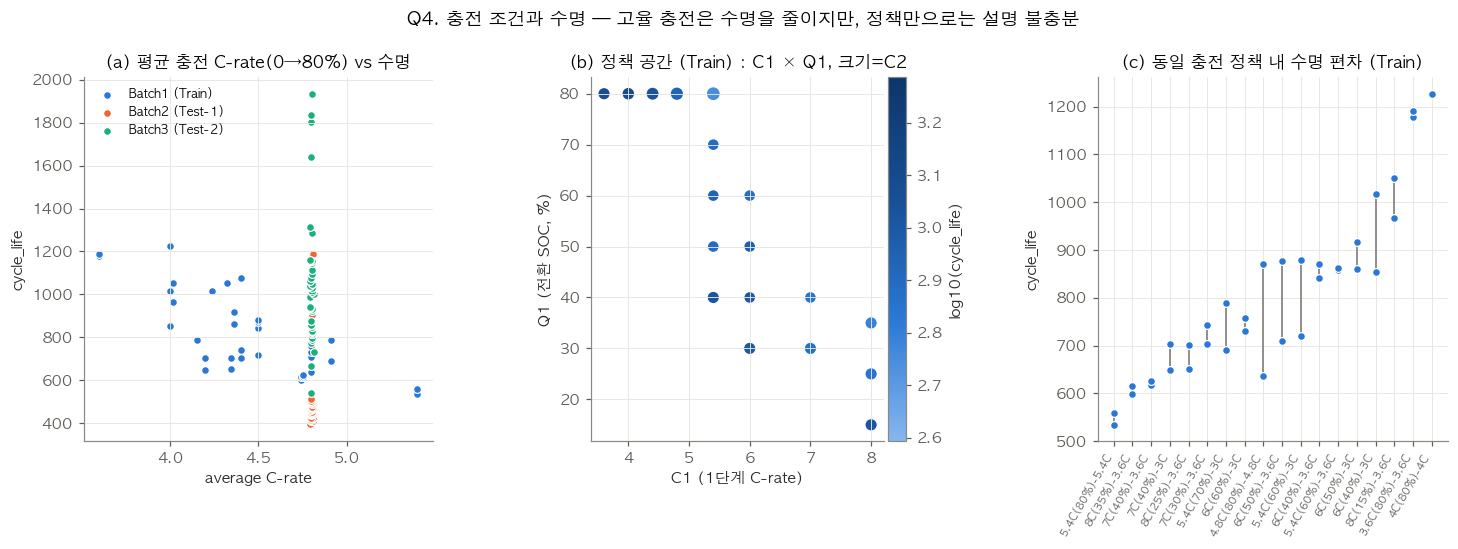

동일 정책 내 수명 CV 중앙값 = 4.18%  vs  전체 Train CV = 23.24%


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), gridspec_kw=dict(wspace=0.45))

# (a) 평균 C-rate vs 수명
for b, g in meta.dropna(subset=["C_avg"]).groupby("batch"):
    axes[0].scatter(g.C_avg, g.cycle_life, s=26, color=BATCH_COLORS[b], edgecolor="white", lw=0.8, label=BATCH_LABELS[b])
axes[0].set(title="(a) 평균 충전 C-rate(0→80%) vs 수명", xlabel="average C-rate", ylabel="cycle_life")
axes[0].legend(fontsize=8)

# (b) 정책 공간 : C1 x Q1, 색 = 수명 (Train)
tr = meta[meta.batch.isin(TRAIN_BATCHES)].dropna(subset=["C1"])
axes[1].scatter(tr.C1, tr.Q1, c=tr.log_life, cmap=LIFE_CMAP, norm=norm, s=30 + 10 * tr.C2,
                edgecolor="white", lw=0.8)
axes[1].set(title="(b) 정책 공간 (Train) : C1 × Q1, 크기=C2", xlabel="C1 (1단계 C-rate)", ylabel="Q1 (전환 SOC, %)")
fig.colorbar(sm, ax=axes[1], pad=0.01).set_label("log10(cycle_life)")

# (c) 동일 정책 내 수명 편차 (Train, 2셀 이상 정책)
rep = tr.groupby("policy").filter(lambda g: len(g) >= 2)
order = rep.groupby("policy").cycle_life.median().sort_values().index
for i, p in enumerate(order):
    y = rep.loc[rep.policy == p, "cycle_life"]
    axes[2].plot([i, i], [y.min(), y.max()], color=INK_MUTED, lw=1.2)
    axes[2].scatter([i] * len(y), y, s=26, color=BATCH_COLORS[1], edgecolor="white", lw=0.8, zorder=3)
axes[2].set_xticks(range(len(order)), order, rotation=60, ha="right", fontsize=7)
axes[2].set(title="(c) 동일 충전 정책 내 수명 편차 (Train)", ylabel="cycle_life")
fig.suptitle("Q4. 충전 조건과 수명 — 고율 충전은 수명을 줄이지만, 정책만으로는 설명 불충분", fontweight="bold", y=1.02)
savefig(fig, "Q4_charging_policy")
plt.show()

if len(rep):
    within = rep.groupby("policy").cycle_life.agg(["count", "mean", "std"]).assign(CV=lambda d: d["std"] / d["mean"])
    print(f"동일 정책 내 수명 CV 중앙값 = {within.CV.median():.2%}  vs  전체 Train CV = {tr.cycle_life.std() / tr.cycle_life.mean():.2%}")

In [20]:
# [추가] Q4 충전 프로토콜별 평균 수명 (배치별)
display(meta.groupby(["batch", "policy"])["cycle_life"].agg(["count", "mean", "std"]).round(0))

count       mean      std
batch policy                                                
1     3.6C(80%)-3.6C                   3 1,182.0000   7.0000
      4.4C(80%)-4.4C                   1 1,074.0000      NaN
      4.8C(80%)-4.8C                   2   753.0000 165.0000
      4C(80%)-4C                       2 1,226.0000   1.0000
      5.4C(40%)-3.6C                   1 1,054.0000      NaN
      5.4C(50%)-3C                     1   788.0000      NaN
      5.4C(60%)-3.6C                   2   860.0000   4.0000
      5.4C(60%)-3C                     2   800.0000 114.0000
      5.4C(70%)-3C                     2   740.0000  69.0000
      5.4C(80%)-5.4C                   2   546.0000  18.0000
      6C(30%)-3.6C                     1 1,014.0000      NaN
      6C(40%)-3.6C                     2   856.0000  20.0000
      6C(40%)-3C                       2   936.0000 115.0000
      6C(50%)-3.6C                     2   792.0000 118.0000
      6C(50%)-3C                       2   888.0000  40.0000
      6C(60%)-3C                       2   744.0000  18.0000
      7C(30%)-3.6C                     2   722.0000  28.0000
      7C(40%)-3.6C                     2   621.0000   6.0000
      7C(40%)-3C                       2   676.0000  40.0000
      8C(15%)-3.6C                     2 1,008.0000  60.0000
      8C(25%)-3.6C                     2   676.0000  36.0000
      8C(35%)-3.6C                     2   608.0000  12.0000
2     3.6C(30%)-6C                     2   421.0000   7.0000
      3.6C(9%)-5C                      2   394.0000   2.0000
      4.65C(44%)-5C                    2   482.0000  23.0000
      4.65C(69%)-6C                    2   452.0000  11.0000
      4.8C(80%)-4.8C                   5   484.0000  30.0000
      4.8C(80%)-4.8C-newstructure      3   872.0000 137.0000
      5.2C(50%)-4.25C                  5   454.0000  21.0000
      5.2C(58%)-4C                     4   478.0000  18.0000
      5.2C(58%)-4C-newstructure        3   962.0000 158.0000
      5.6C(26%)-4.5C                   6   448.0000  29.0000
      5.6C(26%)-4.5C-newstructure      3   991.0000 198.0000
      6C(60%)-3C                       2   400.0000  11.0000
3     3.7C(31%)-5.9C-newstructure      3   660.0000 116.0000
      4.8C(80%)-4.8C-newstructure      4 1,588.0000 351.0000
      5.3C(54%)-4C-newstructure        8 1,074.0000 130.0000
      5.6C(19%)-4.6C-newstructure      7   963.0000 149.0000
      5.6C(36%)-4.3C-newstructure      8   931.0000 135.0000
      5.9C(15%)-4.6C-newstructure      2   867.0000  13.0000
      5.9C(60%)-3.1C-newstructure      2   866.0000 192.0000
      5C(67%)-4C-newstructure          6 1,116.0000 440.0000

**추가 확인 : `-newstructure` 표기 셀 (CSV 정책 문자열 접미사)**
정책 문자열 끝에 `-newstructure` 가 붙은 셀이 Batch2·Batch3 에 있고 Batch1 에는 없습니다. 같은 충전 정책 안에서 이 표기 유무가 수명을 갈라놓는지, Train 이 이 영역을 한 번도 보지 못하는지를 확인합니다.

count   median      min        max
batch new_structure                                    
1     기존                41 842.0000 534.0000 1,227.0000
2     기존                30 451.0000 392.0000   514.0000
      newstructure       9 904.0000 777.0000 1,186.0000
3     newstructure      40 964.5000 541.0000 1,935.0000

[saved] figures/Q4b_new_structure.png


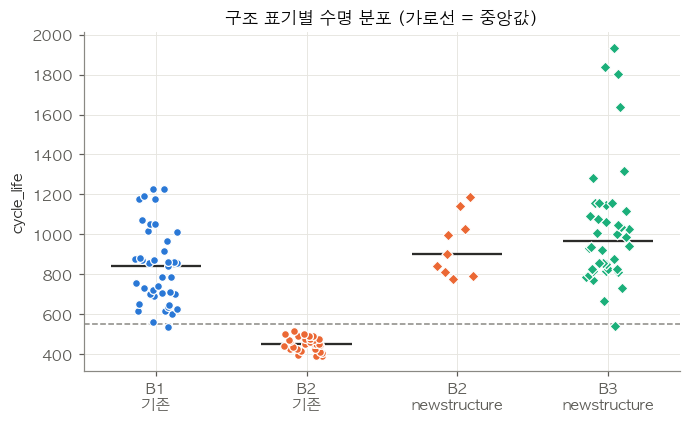

,기존 median,newstructure median,배율
policy_core,,,
4.8C(80%)-4.8C,492.0000,809.0000,1.6443
5.2C(58%)-4C,483.0000,904.0000,1.8716
5.6C(26%)-4.5C,446.0000,997.0000,2.2354


In [21]:
meta["policy_core"] = meta["policy"].str.replace("-newstructure", "", regex=False)
tab = (meta.groupby(["batch", "new_structure"])["cycle_life"].agg(["count", "median", "min", "max"])
       .rename(index={False: "기존", True: "newstructure"}, level=1))
display(tab)

fig, ax = plt.subplots(figsize=(7, 4))
rng = np.random.default_rng(SEED)
xs = {(1, False): 0, (2, False): 1, (2, True): 2, (3, True): 3}
for (b, ns_), x in xs.items():
    g = meta[(meta.batch == b) & (meta.new_structure == ns_)]
    if len(g) == 0: continue
    ax.scatter(x + rng.uniform(-.15, .15, len(g)), g.cycle_life, s=26, color=BATCH_COLORS[b],
               edgecolor="white", lw=.8, zorder=3, marker="o" if not ns_ else "D")
    ax.hlines(g.cycle_life.median(), x - .3, x + .3, color="#2b2b29", lw=1.5)
ax.axhline(LIFE_THRESHOLD, color=INK_MUTED, ls="--", lw=1)
ax.set_xticks(range(4), ["B1\n기존", "B2\n기존", "B2\nnewstructure", "B3\nnewstructure"])
ax.set(ylabel="cycle_life", title="구조 표기별 수명 분포 (가로선 = 중앙값)")
savefig(fig, "Q4b_new_structure")
plt.show()

# 같은 정책(접미사 제거) 안에서의 기존 vs newstructure 수명 비교 (Batch2)
b2 = meta[meta.batch == 2]
cmp_ = b2.pivot_table(index="policy_core", columns="new_structure", values="cycle_life", aggfunc="median").dropna()
cmp_.columns = ["기존 median", "newstructure median"]
cmp_["배율"] = cmp_["newstructure median"] / cmp_["기존 median"]
display(cmp_)

**▶ 결과 기록**
- Spearman(C_avg, 수명) : Batch1 **-0.61** / Batch2 **0.28** / Batch3 **-0.16**
- 동일 정책 내 수명 CV **4.18%** vs 전체 CV **23.24%**
- Batch2·3은 모든 정책의 평균 C-rate가 4.79~4.81C로 사실상 동일 → Spearman(C_avg, 수명) +0.28 / -0.16은 의미 없음 (C-rate 평균이 아니라 C1·전환 SOC·셀 구조가 수명을 가름)
- 같은 정책 중앙값 비교 : 기존 구조 vs newstructure = 1.6~2.2배 (Batch2). Train(Batch1)에는 newstructure가 없음

**도메인 / 비즈니스 인사이트**
- 고율 충전은 음극 표면 **리튬 석출(plating)** 과 발열을 유발해 열화를 가속 → ESS 운영에서 *충전 속도(수익·가용성) vs 수명(교체 비용)* 의 트레이드오프를 정량화할 수 있는 근거.
- 그러나 **같은 정책에서도 수명이 크게 흩어진다면**, 그 차이는 운전 조건이 아니라 셀 고유 편차(제조 품질)에서 온 것 → 운전 조건 로그만으로는 셀별 교체 시점을 맞출 수 없고, **셀 개별 전기화학 신호(ΔQ)** 가 필요하다는 강력한 논거.
- Test 배치의 정책 범위가 Train과 다르면 정책 피처는 외삽 리스크가 큼.

**모델링 가설**
- **H4-1** : 정책 피처(`C_avg`, `C1`, `t80_min`)는 단독 설명력이 제한적이며, ΔQ 피처에 더했을 때 증분 효과가 작다 → Ablation(ΔQ only vs ΔQ+policy)으로 검증.
- **H4-2** : `t80_min` 과 측정 `chargetime` 은 거의 같은 정보 → 둘 중 하나만 사용 (논문은 측정값인 *첫 5사이클 평균 충전시간* 사용).
- **H4-3** : C-rate 효과는 비선형일 가능성 → 선형 모델이면 `log(C_avg)` 변환, 혹은 트리 모델에서 검증.
- **H4-4** : `-newstructure` 셀은 Batch1(Train)에 존재하지 않으므로 **모델 피처로 넣으면 외삽**이 된다(학습 중 항상 0). 피처로 쓰지 않고, 대신 Test-1/Test-2 오차를 구조별로 나눠 보고하여 *분포 이동의 크기*를 정량화한다. 또한 ΔQ(V) 피처가 구조 차이를 흡수해 주는지(구조별 log Var(ΔQ)–수명 관계가 같은 직선 위에 있는지)를 Q3 그림 (c) 에서 확인한다.

---
## Q5. 초기 요약 피처 ↔ cycle_life 상관 & 다중공선성

**확인 내용** : 초기 100 사이클 이내 정보로만 만든 후보 피처(논문 Full model 피처 + 정책 피처)의
① `log10(cycle_life)` 와의 Pearson / Spearman 상관, ② 피처 간 상관 히트맵, ③ VIF(분산팽창계수)

**관전 포인트**
1. 상관 상위 피처가 **ΔQ 계열**인가 Summary 계열인가?
2. |r| > 0.8 로 묶이는 **피처 클러스터** (예: dq_min–dq_mean–dq_var, Tavg–Tmax, QD_2–QD_max)
3. VIF > 10 인 피처 → OLS 계수 불안정 → 규제/차원축소 필요성
4. Pearson과 Spearman 순위가 다르면 → 비선형/이상치 영향

> **누수 방지** : 모든 피처는 **cycle ≤ 100** 의 데이터만 사용합니다. Knee, cycle/cycle_life 같은 타깃 의존 값은 제외.

In [22]:
def lin_fit(s, lo, hi):
    s = s.loc[lo:hi].dropna()
    if len(s) < 3:
        return np.nan, np.nan
    return tuple(np.polyfit(s.index.values.astype(float), s.values, 1))

def at(s, c):
    """사이클 c 값 (없으면 가장 가까운 사이클)."""
    s = s.dropna()
    return s.iloc[np.argmin(np.abs(s.index.values - c))] if len(s) else np.nan

def early_features(cid):
    sdf = SUMMARY[cid]
    qd = clean_qd(sdf).loc[2:CYC_HIGH]
    f = {"cell_id": cid}
    f["QD_2"]            = at(qd, 2)
    f["QD_max_minus_2"]  = qd.max() - f["QD_2"]
    f["QD_100_minus_2"]  = at(qd, CYC_HIGH) - f["QD_2"]
    f["QD_slope_2_100"], f["QD_intercept_2_100"] = lin_fit(qd, 2, CYC_HIGH)
    f["QD_slope_91_100"], _ = lin_fit(qd, 91, CYC_HIGH)
    if "chargetime" in sdf: f["chargetime_avg_2_6"] = sdf["chargetime"].loc[2:6].mean()
    if "Tavg" in sdf:       f["Tavg_mean_2_100"]   = sdf["Tavg"].loc[2:CYC_HIGH].mean()
    if "Tmax" in sdf:       f["Tmax_max_2_100"]    = sdf["Tmax"].loc[2:CYC_HIGH].max()
    if "Tmin" in sdf:       f["Tmin_min_2_100"]    = sdf["Tmin"].loc[2:CYC_HIGH].min()
    if "IR" in sdf:
        ir = sdf["IR"].loc[2:CYC_HIGH].replace(0, np.nan)
        f["IR_min_2_100"]   = ir.min()
        f["IR_diff_100_2"]  = at(ir, CYC_HIGH) - at(ir, 2)
    return f

feat = pd.DataFrame([early_features(c) for c in meta.cell_id])
DQ_FEATS = ["dq_log_var", "dq_log_abs_min", "dq_log_abs_mean", "dq_skew", "dq_kurt"]
POL_FEATS = ["C1", "Q1", "C2", "C_avg", "t80_min"]
data = meta[["cell_id", "batch", "cycle_life", "log_life", "long_life"] + DQ_FEATS + POL_FEATS].merge(feat, on="cell_id")
FEATURES = [c for c in data.columns if c not in ["cell_id", "batch", "cycle_life", "log_life", "long_life"]]
FEATURES = [c for c in FEATURES if data[c].notna().mean() > 0.9 and data[c].std() > 0]
print(f"후보 피처 {len(FEATURES)}개:", FEATURES)
data.to_csv("features_cell_level.csv", index=False)     # 모델링 단계 재사용

후보 피처 22개: ['dq_log_var', 'dq_log_abs_min', 'dq_log_abs_mean', 'dq_skew', 'dq_kurt', 'C1', 'Q1', 'C2', 'C_avg', 't80_min', 'QD_2', 'QD_max_minus_2', 'QD_100_minus_2', 'QD_slope_2_100', 'QD_intercept_2_100', 'QD_slope_91_100', 'chargetime_avg_2_6', 'Tavg_mean_2_100', 'Tmax_max_2_100', 'Tmin_min_2_100', 'IR_min_2_100', 'IR_diff_100_2']


[saved] figures/Q5_target_correlation.png


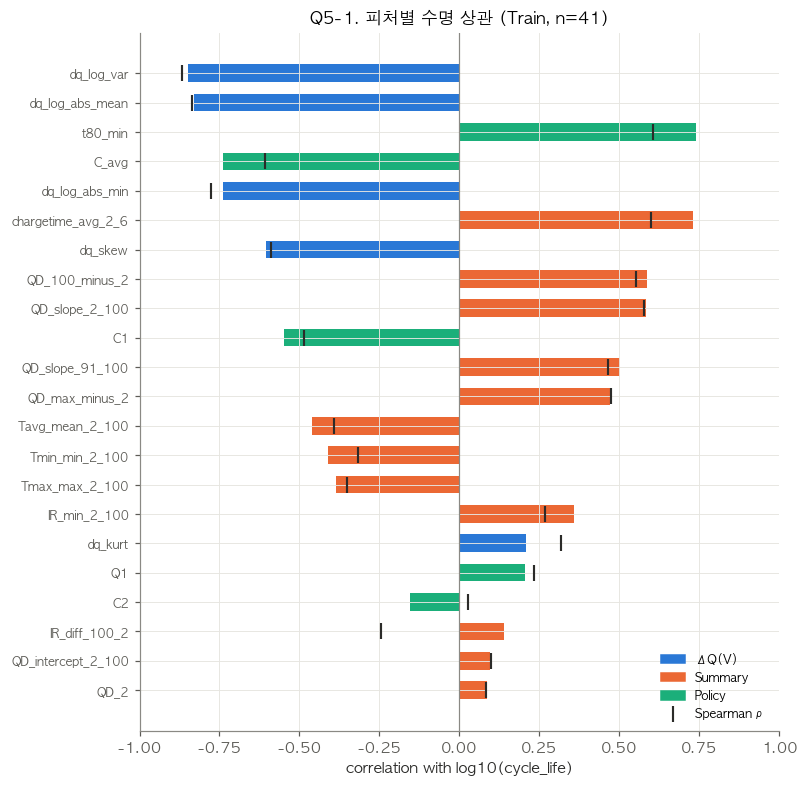

,pearson,spearman
dq_log_var,-0.8471,-0.8663
dq_log_abs_mean,-0.8290,-0.8359
t80_min,0.7413,0.6069
C_avg,-0.7391,-0.6069
dq_log_abs_min,-0.7379,-0.7763
chargetime_avg_2_6,0.7313,0.5983
dq_skew,-0.6036,-0.5887
QD_100_minus_2,0.5887,0.5533
QD_slope_2_100,0.5849,0.5788
C1,-0.5472,-0.4859


In [23]:
train = data[data.batch.isin(TRAIN_BATCHES)].dropna(subset=FEATURES)
corr_t = pd.DataFrame({
    "pearson":  [stats.pearsonr(train[c], train.log_life)[0] for c in FEATURES],
    "spearman": [stats.spearmanr(train[c], train.log_life)[0] for c in FEATURES],
}, index=FEATURES).sort_values("pearson", key=abs)

def group_of(c):
    return "ΔQ(V)" if c.startswith("dq_") else ("Policy" if c in POL_FEATS else "Summary")
GROUP_COLOR = {"ΔQ(V)": "#2a78d6", "Summary": "#eb6834", "Policy": "#1baf7a"}

fig, ax = plt.subplots(figsize=(7.5, 0.32 * len(FEATURES) + 1.2))
y = np.arange(len(corr_t))
ax.barh(y, corr_t.pearson, height=0.6, color=[GROUP_COLOR[group_of(c)] for c in corr_t.index])
sp = ax.scatter(corr_t.spearman, y, marker="|", s=120, color="#2b2b29", zorder=3)
ax.axvline(0, color=INK_MUTED, lw=0.8)
ax.set_yticks(y, corr_t.index, fontsize=8)
ax.set(xlim=(-1, 1), xlabel="correlation with log10(cycle_life)",
       title=f"Q5-1. 피처별 수명 상관 (Train, n={len(train)})")
handles = [plt.Rectangle((0, 0), 1, 1, color=v) for v in GROUP_COLOR.values()]
ax.legend(handles + [sp], list(GROUP_COLOR) + ["Spearman ρ"], loc="lower right", fontsize=8)
savefig(fig, "Q5_target_correlation")
plt.show()
display(corr_t.sort_values("pearson", key=abs, ascending=False))

[saved] figures/Q5_feature_heatmap.png


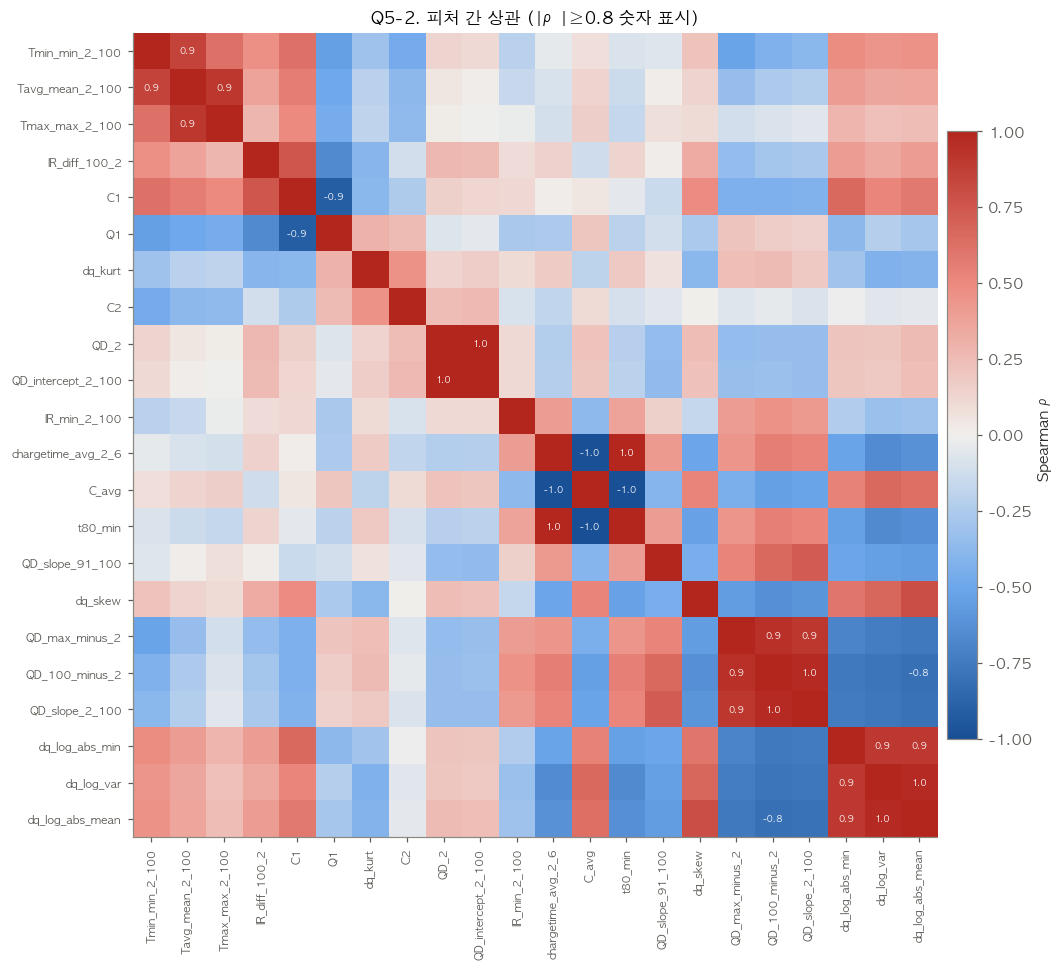

,VIF,flag
QD_2,"52,836.5434",VIF>10
QD_intercept_2_100,"49,939.4737",VIF>10
QD_100_minus_2,"6,828.5124",VIF>10
QD_slope_2_100,"6,063.6471",VIF>10
t80_min,"5,239.9911",VIF>10
chargetime_avg_2_6,"4,364.2267",VIF>10
dq_log_abs_min,"4,243.5263",VIF>10
dq_log_abs_mean,"2,057.2788",VIF>10
dq_log_var,"1,032.8014",VIF>10
dq_kurt,510.5891,VIF>10


|ρ|≥0.8 피처 쌍: [('Tmin_min_2_100', 'Tavg_mean_2_100', 0.85), ('Tavg_mean_2_100', 'Tmax_max_2_100', 0.91), ('C1', 'Q1', -0.91), ('QD_2', 'QD_intercept_2_100', 1.0), ('chargetime_avg_2_6', 'C_avg', -0.98), ('chargetime_avg_2_6', 't80_min', 0.98), ('C_avg', 't80_min', -1.0), ('QD_max_minus_2', 'QD_100_minus_2', 0.94), ('QD_max_minus_2', 'QD_slope_2_100', 0.91), ('QD_100_minus_2', 'QD_slope_2_100', 0.97), ('QD_100_minus_2', 'dq_log_abs_mean', -0.81), ('dq_log_abs_min', 'dq_log_var', 0.9), ('dq_log_abs_min', 'dq_log_abs_mean', 0.9), ('dq_log_var', 'dq_log_abs_mean', 0.97)]


In [24]:
# 피처 간 상관 히트맵 (계층적 클러스터 순서로 정렬)
C = train[FEATURES].corr(method="spearman")
C = C.fillna(0)
link = hierarchy.linkage(1 - C.abs().values[np.triu_indices(len(C), 1)], method="average")
order = [FEATURES[i] for i in hierarchy.leaves_list(link)]
C = C.loc[order, order]

fig, ax = plt.subplots(figsize=(0.42 * len(order) + 2, 0.42 * len(order) + 1))
im = ax.imshow(C.values, cmap=DIV_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(len(order)), order, rotation=90, fontsize=7.5)
ax.set_yticks(range(len(order)), order, fontsize=7.5)
ax.grid(False)
for i in range(len(order)):
    for j in range(len(order)):
        if i != j and abs(C.values[i, j]) >= 0.8:
            ax.text(j, i, f"{C.values[i, j]:.1f}", ha="center", va="center", fontsize=6, color="white")
fig.colorbar(im, ax=ax, shrink=0.7, pad=0.01).set_label("Spearman ρ")
ax.set_title("Q5-2. 피처 간 상관 (|ρ|≥0.8 숫자 표시)")
savefig(fig, "Q5_feature_heatmap")
plt.show()

# VIF = diag(inv(R))  (R: 표준화 피처 상관행렬)
R = train[FEATURES].corr().values
vif = pd.Series(np.diag(np.linalg.pinv(R)), index=FEATURES, name="VIF").sort_values(ascending=False)
high_pairs = [(a, b, round(C.loc[a, b], 2)) for i, a in enumerate(order) for b in order[i + 1:] if abs(C.loc[a, b]) >= 0.8]
display(vif.to_frame().assign(flag=lambda d: np.where(d.VIF > 10, "VIF>10", "")))
print("|ρ|≥0.8 피처 쌍:", high_pairs)

In [25]:
# 다중공선성 고려 피처 후보 (상관 높은 순으로 추가, 기존 선택 피처와 |ρ|<0.8 인 것만)
selected = []
for c in corr_t.sort_values("pearson", key=abs, ascending=False).index:
    if all(abs(C.loc[c, s]) < 0.8 for s in selected):
        selected.append(c)
print("공선성 정리 후 후보 피처 순위:", selected)

공선성 정리 후 후보 피처 순위: ['dq_log_var', 't80_min', 'dq_skew', 'QD_100_minus_2', 'C1', 'QD_slope_91_100', 'Tavg_mean_2_100', 'IR_min_2_100', 'dq_kurt', 'C2', 'IR_diff_100_2', 'QD_intercept_2_100']


In [26]:
# [추가] Q5 배치별 비교 : 피처 ↔ log 수명 상관 (부호/크기가 배치 간 일관된가?)
cols = ["dq_log_var", "dq_log_abs_mean", "C_avg", "chargetime_avg_2_6", "QD_100_minus_2", "QD_slope_2_100", "Tavg_mean_2_100", "IR_min_2_100"]
rows = {f: {**{BATCH_LABELS[b]: g[f].corr(g.log_life) for b, g in data.groupby("batch")}, "전체": data[f].corr(data.log_life)} for f in cols}
display(pd.DataFrame(rows).T)

,Batch1 (Train),Batch2 (Test-1),Batch3 (Test-2),전체
dq_log_var,-0.8471,-0.9047,-0.8032,-0.8747
dq_log_abs_mean,-0.8290,-0.8734,-0.7571,-0.8549
C_avg,-0.7391,0.3496,-0.0242,-0.2938
chargetime_avg_2_6,0.7313,-0.9415,0.5552,0.3136
QD_100_minus_2,0.5887,-0.2302,0.3911,-0.0312
QD_slope_2_100,0.5849,-0.3726,0.4307,-0.1250
Tavg_mean_2_100,-0.4611,0.3933,-0.0422,0.2285
IR_min_2_100,0.3588,-0.5735,0.3511,-0.3322


**▶ 결과 기록**
- 상관 Top3 : **dq_log_var** (r=**-0.8471**), **dq_log_abs_mean** (r=**-0.8290**), **t80_min** (r=**0.7413**) (또는 **C_avg**, r=**-0.7391**) → ΔQ 계열 / Summary(정책 포함) 계열 비중 **ΔQ 계열이 1, 2위를 차지 (3위 이하는 충전시간/C-rate 계열) / 배치별 비교는 아래 추가 셀 참고: dq_log_var만 세 배치에서 같은 부호(-0.85 / -0.90 / -0.80)**
- |ρ|≥0.8 클러스터 : **총 14개 쌍** (용량군: `QD_2`↔`QD_intercept`, 시간/C-rate군: `C_avg`↔`t80_min`↔`chargetime`, ΔQ군: `dq_log_var`↔`dq_log_abs_mean`↔`dq_log_abs_min`, 온도군: `Tmin`↔`Tavg`↔`Tmax`) / VIF>10 피처 : **전체 22개 중 19개** (C2, IR_diff, IR_min 3개를 제외한 86.4%가 극심한 공선성 보유)

**도메인 / 비즈니스 인사이트**
- ΔQ 계열 피처가 상위권을 차지한다면, **용량·온도·내부저항 같은 BMS 기본 로그보다 방전 곡선 형태가 수명 정보를 더 많이 담고 있다**는 의미 → ESS BMS가 고해상도 방전 전압-용량 데이터를 저장해야 하는 근거(데이터 수집 정책 제안).
- 온도·내부저항 계열은 단독 상관은 낮아도 ΔQ가 설명하지 못하는 부분(발열, 저항 증가)을 보완할 수 있습니다.

**모델링 가설**
- **H5-1** : ΔQ 피처끼리(min/mean/var) VIF가 매우 크므로 OLS는 계수가 불안정 → **ElasticNet**(L1로 대표 피처 선택 + L2로 상관 그룹 안정화)이 소표본 + 공선성 환경에 최적.
- **H5-2** : 논문의 3단계 피처셋 (Variance ⊂ Discharge ⊂ Full) 을 그대로 재현해, 피처 추가가 성능을 올리는지 단계별로 검증한다.
- **H5-3** : 피처 수(~20) 대비 Train 셀 수(~41)가 적으므로 p/n 비율을 낮게(≤ 1/4) 유지한다.

---
## 6. 모델링 전략 (Modeling Strategy)

### 6-1. 후보 모델군 & 선정 근거

| 순위 | 모델 | 역할 | 선정 근거 (소표본 120셀 / Train 41셀 + 배터리 도메인) |
|---|---|---|---|
| Baseline | **Linear (log Var ΔQ 단일 피처)** | 기준선 | 논문 Variance model 재현. 모든 모델은 이 기준선을 넘어야 의미 있음 |
| 주력 ① | **ElasticNet** (target = log10 life) | 메인 | 논문 채택 모델. L1 → 피처 선택, L2 → 공선성 그룹 안정화. 계수 = 물리적 해석 가능 |
| 주력 ② | **Ridge / PLS** | 비교 | 공선성 강한 ΔQ 피처를 버리지 않고 축소·잠재변수화. 분산 매우 낮음 |
| 확장 ③ | **Gaussian Process Regression** | 불확실성 | 소표본에 강하고 **예측 구간** 제공 → "교체 시점 ± 신뢰구간"으로 리스크 관리 의사결정에 바로 활용 |
| 비교 ④ | **LightGBM / GBM (얕은 트리, 강한 규제)** | 비선형 체크 | 비선형·상호작용 확인용. 단, 41셀에서는 과적합·**학습 범위 밖 외삽 불가** 한계 → 주력 X |

**과적합 방지 장치** : log 타깃, 표준화 후 규제, 피처 ≤ 10개, 하이퍼파라미터는 내부 CV에서만 결정(Nested), 트리는 `max_depth≤2`, `min_child_samples≥5`.

### 6-2. 검증 전략 (Cell-level Leakage 방지)

1. **분할 단위 = 셀** : 1 row = 1 cell 로 피처를 집계한 뒤 분할. 같은 셀의 사이클이 Train/Valid에 동시에 들어가는 *사이클 단위 분할 금지*.
2. **Batch1 내부 분할** : 수명 4분위로 층화한 **Hold-out 20%(≈8셀)** + 나머지에서 **Repeated 5-Fold × 10 (CV)**. 셀 수가 적어 단일 분할은 운에 크게 좌우되므로 반복 CV의 평균±표준편차로 보고.
3. **전처리 누수 차단** : `StandardScaler`·피처 선택·하이퍼파라미터 탐색은 모두 `Pipeline` 안에서 fold별로 fit.
4. **정책 일반화 점검(선택)** : `GroupKFold(groups=charging_policy)` → 처음 보는 충전 조건에 대한 일반화 확인.
5. **Batch2 / Batch3 는 최종 1회만 평가** (설계 단계에서는 타깃 분포만 확인, 모델 선택에 사용 금지).
6. **피처 누수 체크리스트** : cycle ≤ 100 데이터만 사용 / knee·cycle_life 정규화 값 사용 금지 / Test 셀을 포함한 전체 데이터로 scaler·결측치 대체 fit 금지.

**평가 지표** : MAPE(%) — 논문 비교, RMSE(cycles) — 실무 오차 크기, 파생 분류 Accuracy(≥550) — 과제 2 관점 보완

In [27]:
from sklearn.model_selection import train_test_split, RepeatedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNetCV, RidgeCV
from sklearn.cross_decomposition import PLSRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import make_scorer

# ---------------- 피처셋 (논문 3단계 재현) ----------------
def keep(cols): return [c for c in cols if c in FEATURES]
FEATURE_SETS = {
    "variance":  keep(["dq_log_var"]),
    "discharge": keep(["dq_log_var", "dq_log_abs_min", "dq_skew", "dq_kurt", "QD_2", "QD_max_minus_2"]),
    "full":      keep(["dq_log_var", "dq_log_abs_min", "QD_slope_2_100", "QD_intercept_2_100", "QD_2",
                       "chargetime_avg_2_6", "Tavg_mean_2_100", "IR_min_2_100", "IR_diff_100_2"]),
}

# ---------------- Batch1 → Train / Hold-out (셀 단위, 수명 층화) ----------------
b1 = data[data.batch.isin(TRAIN_BATCHES)].dropna(subset=FEATURE_SETS["full"]).reset_index(drop=True)
strata = pd.qcut(b1.log_life, q=4, labels=False)
tr_idx, ho_idx = train_test_split(b1.index, test_size=0.2, stratify=strata, random_state=SEED)
TR, HO = b1.loc[tr_idx], b1.loc[ho_idx]
assert set(TR.cell_id).isdisjoint(HO.cell_id), "셀 누수 발생!"
print(f"Train {len(TR)} cells / Hold-out {len(HO)} cells (셀 중복 없음)")

# ---------------- 지표 : log 타깃 → 사이클로 역변환 후 계산 ----------------
def mape_cycles(y_true_log, y_pred_log):
    yt, yp = 10 ** np.asarray(y_true_log), 10 ** np.ravel(y_pred_log)
    return np.mean(np.abs(yp - yt) / yt) * 100
def rmse_cycles(y_true_log, y_pred_log):
    yt, yp = 10 ** np.asarray(y_true_log), 10 ** np.ravel(y_pred_log)
    return np.sqrt(np.mean((yp - yt) ** 2))
def cls_acc(y_true_log, y_pred_log):
    yt, yp = 10 ** np.asarray(y_true_log), 10 ** np.ravel(y_pred_log)
    return np.mean((yt >= LIFE_THRESHOLD) == (yp >= LIFE_THRESHOLD)) * 100
SCORING = {"MAPE": make_scorer(mape_cycles, greater_is_better=False),
           "RMSE": make_scorer(rmse_cycles, greater_is_better=False),
           "ACC550": make_scorer(cls_acc)}

MODELS = {
    "Linear":     lambda: make_pipeline(StandardScaler(), LinearRegression()),
    "ElasticNet": lambda: make_pipeline(StandardScaler(), ElasticNetCV(l1_ratio=[.1, .5, .9, .99], cv=4, max_iter=50000, random_state=SEED)),
    "Ridge":      lambda: make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 3, 30))),
    "PLS(2)":     lambda: make_pipeline(StandardScaler(), PLSRegression(n_components=2)),
    "GPR":        lambda: make_pipeline(StandardScaler(), GaussianProcessRegressor(
                        ConstantKernel() * RBF(length_scale=3.0) + WhiteKernel(), normalize_y=True, random_state=SEED)),
    "GBM(d=2)":   lambda: GradientBoostingRegressor(max_depth=2, n_estimators=150, learning_rate=0.05,
                                                    subsample=0.8, min_samples_leaf=4, random_state=SEED),
}

Train 32 cells / Hold-out 9 cells (셀 중복 없음)


In [28]:
# ---------------- Repeated 5-fold CV (Train) + Hold-out ----------------
cv = RepeatedKFold(n_splits=5, n_repeats=10, random_state=SEED)
results = []
for fs_name, cols in FEATURE_SETS.items():
    for m_name, make in MODELS.items():
        if fs_name == "variance" and m_name not in ("Linear", "GPR"):
            continue                                    # 단일 피처엔 규제/PLS 의미 없음
        if m_name == "PLS(2)" and len(cols) < 2:
            continue
        sc = cross_validate(make(), TR[cols], TR.log_life, cv=cv, scoring=SCORING)
        model = make().fit(TR[cols], TR.log_life)
        pred = model.predict(HO[cols])
        results.append({
            "feature_set": fs_name, "model": m_name, "n_feat": len(cols),
            "CV_MAPE": -sc["test_MAPE"].mean(), "CV_MAPE_sd": sc["test_MAPE"].std(),
            "CV_RMSE": -sc["test_RMSE"].mean(), "CV_ACC550": sc["test_ACC550"].mean(),
            "HO_MAPE": mape_cycles(HO.log_life, pred), "HO_RMSE": rmse_cycles(HO.log_life, pred),
        })
res = pd.DataFrame(results).sort_values("CV_MAPE").reset_index(drop=True)
display(res)
print("※ 논문 벤치마크: MAPE 9.1% (Test). 위 수치는 Batch1 내부 검증값이며 Test 성능과 다를 수 있음.")

,feature_set,model,n_feat,CV_MAPE,CV_MAPE_sd,CV_RMSE,CV_ACC550,HO_MAPE,HO_RMSE
0,variance,GPR,1,8.8843,2.3253,89.1805,96.9524,7.4515,79.9821
1,discharge,GPR,6,9.3456,3.8059,111.6836,96.6667,5.0934,83.2290
2,full,GPR,9,9.6340,2.9447,87.3581,96.9524,7.6787,105.4049
3,full,GBM(d=2),9,9.8186,2.4178,89.8026,96.9524,8.1129,88.7310
4,discharge,GBM(d=2),6,10.4156,3.5523,104.0018,96.9524,9.7492,112.1761
5,discharge,Ridge,6,10.8780,6.2583,123.3798,99.7143,13.5868,330.0000
6,discharge,PLS(2),6,11.4657,4.2827,127.1375,97.6190,11.8715,230.2327
7,discharge,ElasticNet,6,11.7596,6.2314,126.6819,97.5238,13.6157,326.6181
8,discharge,Linear,6,11.8712,6.7843,145.9183,100.0000,15.4778,349.3025
9,full,PLS(2),9,12.0534,4.2007,127.8493,97.5714,9.3388,112.2264


※ 논문 벤치마크: MAPE 9.1% (Test). 위 수치는 Batch1 내부 검증값이며 Test 성능과 다를 수 있음.


[saved] figures/M_model_comparison.png


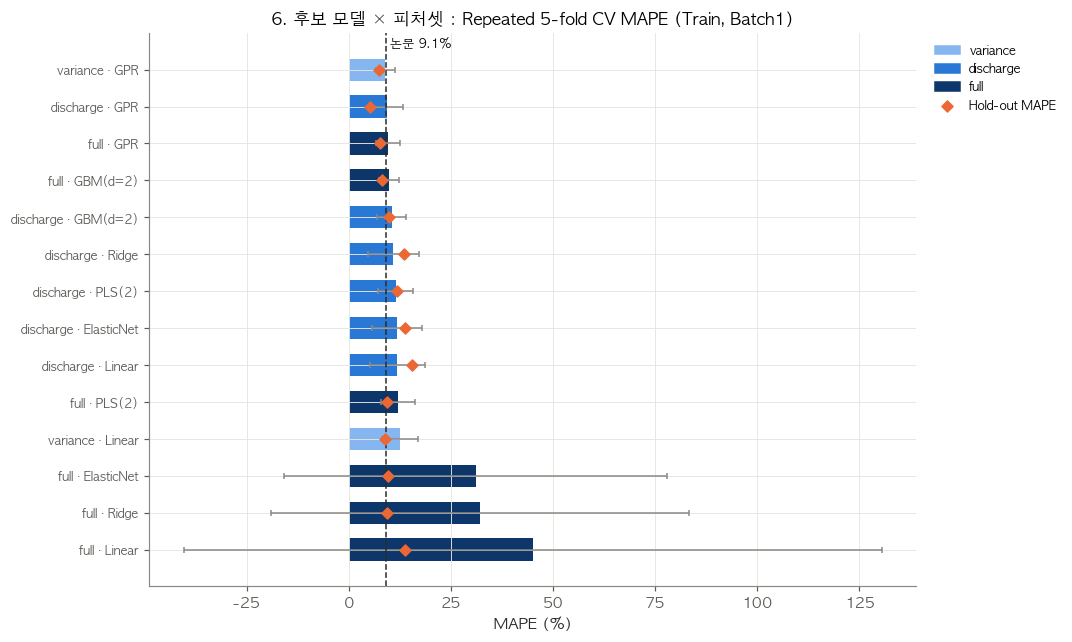

In [29]:
fig, ax = plt.subplots(figsize=(9, 0.38 * len(res) + 1.2))
lab = res.feature_set + " · " + res.model
y = np.arange(len(res))[::-1]
fs_col = {"variance": "#86b6ef", "discharge": "#2a78d6", "full": "#0d366b"}
ax.barh(y, res.CV_MAPE, xerr=res.CV_MAPE_sd, height=0.6, color=res.feature_set.map(fs_col),
        error_kw=dict(ecolor=INK_MUTED, lw=1, capsize=2))
ho = ax.scatter(res.HO_MAPE, y, marker="D", s=26, color="#eb6834", zorder=3)
ax.axvline(9.1, color="#2b2b29", ls="--", lw=1); ax.text(9.1, y.max() + 0.6, " 논문 9.1%", fontsize=8)
ax.set_yticks(y, lab, fontsize=8)
ax.set(xlabel="MAPE (%)", title="6. 후보 모델 × 피처셋 : Repeated 5-fold CV MAPE (Train, Batch1)")
handles = [plt.Rectangle((0, 0), 1, 1, color=v) for v in fs_col.values()]
ax.legend(handles + [ho], list(fs_col) + ["Hold-out MAPE"], fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1))
savefig(fig, "M_model_comparison")
plt.show()

In [30]:
# ---------------- 최종 평가 (DAY 2 이후, 모델 확정 후 1회만 실행) ----------------
RUN_TEST = False
BEST_FS, BEST_MODEL = "variance", "GPR"   # DAY1 예비 CV 최저(8.9%). full·ElasticNet은 CV 31%로 불안정 → DAY2에서 재선정

if RUN_TEST:
    cols = FEATURE_SETS[BEST_FS]
    final = MODELS[BEST_MODEL]().fit(b1[cols], b1.log_life)     # Batch1 전체로 재학습
    for b in [2, 3]:
        te = data[data.batch == b].dropna(subset=cols)
        p = final.predict(te[cols])
        print(f"{BATCH_LABELS[b]}: MAPE={mape_cycles(te.log_life, p):.1f}%  RMSE={rmse_cycles(te.log_life, p):.0f} cycles  "
              f"ACC550={cls_acc(te.log_life, p):.1f}%")

---
## 7. DAY 1 요약 — 가설 체인

| Q | 핵심 확인 | 인사이트 | 모델링 가설 → 검증 방법 |
|---|---|---|---|
| Q1 | 수명 우측 꼬리, 배치 간 범위 차이 | 단수명 셀 놓침 비용이 큼 | log10 타깃 / 선형계 주력 → raw vs log CV 비교 |
| Q2 | 100 사이클까지 용량 거의 불변, 후반 Knee | 용량 추이 외삽은 수명 과대평가 | 용량 피처 단독은 약함 → Summary-only 모델 성능 확인 |
| Q3 | ΔQ(V) 형태가 수명과 강한 상관 | 열화 메커니즘의 초기 흔적, 해석 가능 | Var(ΔQ) 단일 피처 베이스라인 |
| Q4 | 고율 충전 ↔ 단수명, 동일 정책 내 편차 큼 | 운전 로그만으로는 셀별 교체 시점 예측 불가 | 정책 피처 증분 효과 작음 → Ablation |
| Q5 | ΔQ 피처 상위·상호 공선성 큼 | BMS 고해상도 방전 데이터 저장 필요 | ElasticNet + 3단계 피처셋 비교 |
